# GeoLife CP2 — Home / Office / POI Baseline

**Mục tiêu:** xây một baseline Home / Office có thể giải thích được, bắt đầu từ frozen CP1 stay events chứ không từ raw GPS.

### Câu hỏi lớn

1. user có đủ repeated history để suy semantic location không;
2. DBSCAN và complete-link trade-off ra sao khi gom recurring location;
3. UTC timestamps phải chuyển sang behavioral local time theo policy nào;
4. night/daytime evidence nên tính trên whole stay hay exact interval overlap;
5. khi nào nên **abstain** thay vì ép HOME/OFFICE;
6. production implementation có reproduce đúng notebook decision trên full release không.

### Nguyên tắc

```text
CP1 cleaning/stays
      ↓
user-level history
      ↓
geography + timezone scope
      ↓
compact recurring locations
      ↓
behavioral-time evidence
      ↓
abstention + evidence strength
```

> GeoLife không có direct HOME/OFFICE ground truth. Vì vậy notebook đánh giá **coverage, stability, support và plausibility**, không báo accuracy.

> HOME/OFFICE là sensitive derived locations. Không commit precise user-level inferred coordinates hoặc private caches vào repo.

Design contract: `docs/design/03_home_office_baseline_contract.md`.


In [1]:
from pathlib import Path
from time import perf_counter
from zoneinfo import ZoneInfo
from IPython.display import display
import os
import pickle
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, DBSCAN

REPO_URL = "https://github.com/tanh1c/geolife.git"
REPO_BRANCH = os.environ.get(
    "GEOLIFE_REPO_BRANCH",
    "cp2-dbscan-benchmark-audit",
)
REPO_DIR = Path(os.environ.get("GEOLIFE_REPO_DIR", "/tmp/geolife"))
VOLUME_ROOT = Path("/mnt/geolife-data")
CACHE_DIR = VOLUME_ROOT / "cache" / "cp2_home_office"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def resolve_data_root():
    env_root = os.environ.get("GEOLIFE_DATA_ROOT")
    candidates = ([Path(env_root)] if env_root else []) + [
        VOLUME_ROOT / "extracted" / "Geolife Trajectories 1.3" / "Data",
        VOLUME_ROOT / "Data",
    ]
    for candidate in candidates:
        if candidate.is_dir() and any(candidate.glob("*/Trajectory/*.plt")):
            return candidate
    for candidate in sorted(VOLUME_ROOT.glob("**/Data")):
        if candidate.is_dir() and any(candidate.glob("*/Trajectory/*.plt")):
            return candidate
    raise FileNotFoundError("GeoLife Data folder not found")

def ensure_repo():
    if (REPO_DIR / ".git").exists():
        subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin"], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", REPO_BRANCH], check=True)
    else:
        subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)

DATA_ROOT = resolve_data_root()
ensure_repo()
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
if str(REPO_DIR / "src") not in sys.path:
    sys.path.insert(0, str(REPO_DIR / "src"))

from notebooks.eda_core import read_plt
from geolife.geo.distance import haversine_m
from geolife.staypoints import clean_trajectory, detect_staypoints
from geolife.model import HomeOfficeConfig, build_semantic_locations, infer_home_office

BASELINE = {
    "same_second_radius_m": 10.0,
    "max_gap_s": 300.0,
    "hard_speed_guard_kmh": 1200.0,
    "distance_threshold_m": 200.0,
    "min_dwell_s": 1200.0,
}

files = sorted(DATA_ROOT.glob("*/Trajectory/*.plt"))
print("Repo branch:", REPO_BRANCH)
print("Data root:", DATA_ROOT)
print("Trajectory files:", f"{len(files):,}")
print("Cache dir:", CACHE_DIR)
print("Frozen CP1 baseline:", BASELINE)


Cloning into '/tmp/geolife'...


Repo branch: cp2-dbscan-benchmark-audit
Data root: /mnt/geolife-data/extracted/Geolife Trajectories 1.3/Data
Trajectory files: 18,670
Cache dir: /mnt/geolife-data/cache/cp2_home_office
Frozen CP1 baseline: {'same_second_radius_m': 10.0, 'max_gap_s': 300.0, 'hard_speed_guard_kmh': 1200.0, 'distance_threshold_m': 200.0, 'min_dwell_s': 1200.0}


## 1. Materialize frozen CP1 stays ở cấp user

CP1 full-release audit đã xác nhận **5,821 stays** trên 18,670 files, nhưng cache cũ chủ yếu là per-file summary. CP2 cần actual stay rows để gom history theo user.

### Vì sao phải materialize lại actual stays?

Home/Office cần các field mà summary per-file không đủ:

- `user_id`;
- arrival / departure UTC;
- duration;
- stay representative coordinate;
- source-file lineage.

### Reproducibility gate

Section này phải kết thúc bằng:

```text
len(stays) == 5,821
```

Nếu không reconcile đúng CP1 total thì phải dừng — semantic stage không được âm thầm chạy trên một upstream dataset khác.

### Cache design

Run đầu có thể chậm vì phải đọc 18,670 `.plt` files. Notebook checkpoint mỗi 500 files và lưu final private cache bằng pandas pickle để không phụ thuộc `pyarrow`.

Cache chỉ là execution artifact trên mounted volume, không phải dataset để commit.

In [2]:
STAYS_CACHE = CACHE_DIR / "stays_baseline_v1.pkl"
PARTIAL_CACHE = CACHE_DIR / "stays_baseline_v1.partial.pkl"
EXPECTED_CP1_STAYS = 5821

def user_id_from_path(path):
    return path.parent.parent.name

def process_file(path):
    raw = read_plt(path)[["timestamp", "latitude", "longitude"]]
    cleaned = clean_trajectory(
        raw,
        same_second_radius_m=BASELINE["same_second_radius_m"],
        max_gap_s=BASELINE["max_gap_s"],
        hard_speed_guard_kmh=BASELINE["hard_speed_guard_kmh"],
    )
    stays = detect_staypoints(
        cleaned,
        distance_threshold_m=BASELINE["distance_threshold_m"],
        min_dwell_s=BASELINE["min_dwell_s"],
    )
    if stays.empty:
        return []
    user_id = user_id_from_path(path)
    out = []
    for row in stays.itertuples(index=False):
        out.append({
            "user_id": user_id,
            "source_file": str(path),
            "sequence_id": int(row.sequence_id),
            "arrival_time_utc": row.arrival_time,
            "departure_time_utc": row.departure_time,
            "duration_s": float(row.duration_s),
            "latitude": float(row.latitude),
            "longitude": float(row.longitude),
            "n_points": int(row.n_points),
        })
    return out

if STAYS_CACHE.exists():
    stays = pd.read_pickle(STAYS_CACHE)
    print("Loaded:", STAYS_CACHE)
else:
    if PARTIAL_CACHE.exists():
        with PARTIAL_CACHE.open("rb") as f:
            partial = pickle.load(f)
        processed = set(partial["processed_files"])
        rows = list(partial["rows"])
        print("Resuming partial:", f"{len(processed):,}/{len(files):,} files")
    else:
        processed = set()
        rows = []

    t0 = perf_counter()
    completed_this_run = 0

    for path in files:
        key = str(path)
        if key in processed:
            continue

        rows.extend(process_file(path))
        processed.add(key)
        completed_this_run += 1

        if completed_this_run % 500 == 0:
            elapsed_min = (perf_counter() - t0) / 60
            overall_done = len(processed)
            rate = completed_this_run / max(elapsed_min, 1e-9)
            remaining = len(files) - overall_done
            eta_min = remaining / max(rate, 1e-9)
            print(
                f"{overall_done:,}/{len(files):,} files | "
                f"{len(rows):,} stays | "
                f"elapsed {elapsed_min:.1f} min | ETA ~{eta_min:.1f} min"
            )
            with PARTIAL_CACHE.open("wb") as f:
                pickle.dump(
                    {"processed_files": sorted(processed), "rows": rows},
                    f,
                    protocol=pickle.HIGHEST_PROTOCOL,
                )

    stays = pd.DataFrame(rows)
    stays["arrival_time_utc"] = pd.to_datetime(stays["arrival_time_utc"], utc=True)
    stays["departure_time_utc"] = pd.to_datetime(stays["departure_time_utc"], utc=True)
    stays = stays.sort_values(
        ["user_id", "arrival_time_utc", "source_file"], kind="stable"
    ).reset_index(drop=True)
    stays.to_pickle(STAYS_CACHE)
    if PARTIAL_CACHE.exists():
        PARTIAL_CACHE.unlink()
    print("Saved:", STAYS_CACHE)

print("Materialized stays:", f"{len(stays):,}")
print("Users with stays:", stays["user_id"].nunique())
assert len(stays) == EXPECTED_CP1_STAYS, (
    f"Expected {EXPECTED_CP1_STAYS} CP1 stays, got {len(stays)}"
)
display(stays.head())

Loaded: /mnt/geolife-data/cache/cp2_home_office/stays_baseline_v1.pkl
Materialized stays: 5,821
Users with stays: 136


Exact user-level stay rows/timestamps/coordinates/source files omitted from committed notebook for privacy.


### Kết luận phần 1

Full run đã reproduce chính xác:

- **5,821 stays**;
- **136 users** có ít nhất một stay.

Điều này đóng contract giữa CP1 và CP2: mọi semantic analysis về sau bắt đầu từ đúng production stay behavior đã validate.

**Không được suy ra:** 136 users có stays không có nghĩa 136 users đủ evidence để infer HOME/OFFICE. History sufficiency là gate riêng ở phần tiếp theo.

## 2. Kiểm tra mỗi user có đủ lịch sử để suy ra Home/Office hay chưa

### Vì sao cần bước này?

Home và Office là những nơi user thường **quay lại nhiều lần**.

Nếu một user chỉ có 1–2 stays, ta chưa có đủ bằng chứng để nói location nào là Home hay Office.

Ví dụ:

```text
User A:
- 1 stay ở một quán cà phê

User B:
- 20 stays lặp lại ở cùng một khu vực
````

Với User A, nếu vẫn ép model phải trả HOME/OFFICE thì rất dễ tạo ra nhãn sai.

Vì vậy trước khi làm semantic inference, ta cần kiểm tra:

> Mỗi user có bao nhiêu dữ liệu lịch sử và mức support có đủ mạnh hay không?

---

### Section này đo những gì?

Với mỗi user, ta tính:

* `stays`: tổng số stay đã phát hiện;
* `active_utc_dates`: stay xuất hiện trên bao nhiêu ngày khác nhau;
* `first_stay_utc`, `last_stay_utc`: stay đầu tiên và cuối cùng;
* `observation_span_days`: khoảng thời gian từ stay đầu đến stay cuối;
* `total_dwell_h`: tổng thời gian user ở trong các stays;
* `median_stay_min`: thời lượng stay điển hình.

Ví dụ:

```text
stays = 10
active_utc_dates = 6
observation_span_days = 30
```

nghĩa là user có 10 stays, trải trên 6 ngày khác nhau, trong khoảng 30 ngày quan sát.

---

### Vì sao cần cả `stays` và `active_utc_dates`?

Hai metric này đo hai khía cạnh khác nhau.

Ví dụ:

```text
User A:
10 stays nhưng tất cả trong cùng 1 ngày

User B:
10 stays trải trên 8 ngày
```

Cả hai đều có `10 stays`, nhưng User B cho thấy behavior lặp lại theo thời gian rõ hơn.

Vì Home/Office là hành vi lặp lại, số ngày có dữ liệu cũng quan trọng chứ không chỉ số lượng stays.

---

### Kết quả trên GeoLife

Measured support:

| history condition        |   users |
| ------------------------ | ------: |
| >=1 stay                 | **136** |
| >=2 stays                | **120** |
| >=5 stays                |  **99** |
| >=10 stays               |  **81** |
| stays trên >=2 UTC dates | **114** |
| >=5 UTC dates            |  **83** |
| >=10 UTC dates           |  **62** |

GeoLife có tổng cộng **182 users**.

Nhưng chỉ:

```text
136 / 182 users
```

có ít nhất một detected stay.

Tức là:

```text
182 - 136 = 46 users
```

không có stay nào dưới CP1 baseline.

Ngay trong 136 users có stay, mức độ dữ liệu cũng rất khác nhau:

```text
136 users có >=1 stay
120 users có >=2 stays
99 users có >=5 stays
81 users có >=10 stays
```

Nghĩa là càng yêu cầu history mạnh hơn thì số user đủ điều kiện càng giảm.

---

### Tại sao đây dẫn đến `abstention`?

Ta không muốn pipeline hoạt động theo kiểu:

```text
mọi user
→ bắt buộc phải có HOME
→ bắt buộc phải có OFFICE
```

Thay vào đó:

```text
đủ evidence
→ emit HOME/OFFICE

không đủ evidence
→ abstain
```

`abstain` nghĩa là:

> model chủ động không đưa ra nhãn vì dữ liệu hiện tại chưa đủ mạnh.

Đây là behavior mong muốn, không phải lỗi.

---

### Lưu ý về UTC dates

Ở section này, `active_utc_dates` chỉ dùng để đo **độ phủ lịch sử theo ngày**.

Ta chưa dùng nó để suy ra:

```text
ban đêm
giờ làm việc
weekday / weekend
```

vì các khái niệm đó phụ thuộc vào **local timezone**.

Timezone behavioral chỉ được áp dụng sau geography/timezone gate ở các section tiếp theo.


In [3]:
user_history = (
    stays.assign(
        arrival_utc_date=stays["arrival_time_utc"].dt.date,
    )
    .groupby("user_id")
    .agg(
        stays=("user_id", "size"),
        active_utc_dates=("arrival_utc_date", "nunique"),
        first_stay_utc=("arrival_time_utc", "min"),
        last_stay_utc=("departure_time_utc", "max"),
        total_dwell_h=("duration_s", lambda s: s.sum() / 3600.0),
        median_stay_min=("duration_s", lambda s: s.median() / 60.0),
    )
)

user_history["observation_span_days"] = (
    user_history["last_stay_utc"] - user_history["first_stay_utc"]
).dt.total_seconds() / 86400.0

display(
    user_history[
        ["stays", "active_utc_dates", "observation_span_days", "total_dwell_h", "median_stay_min"]
    ].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99])
)

print("Users with >=1 stay:", len(user_history))
for n in [2, 3, 5, 10]:
    print(f"Users with >= {n} stays:", int((user_history["stays"] >= n).sum()))
for n in [2, 3, 5, 10]:
    print(
        f"Users with stays on >= {n} distinct UTC dates:",
        int((user_history["active_utc_dates"] >= n).sum()),
    )

,stays,active_utc_dates,observation_span_days,total_dwell_h,median_stay_min
count,136.000000,136.000000,136.000000,136.000000,136.000000
mean,42.801471,17.897059,164.561395,25.021031,28.891789
std,67.237426,23.634338,303.113923,43.034910,9.672288
min,1.000000,1.000000,0.013889,0.333333,20.000000
10%,1.000000,1.000000,0.044184,0.735417,23.033333
25%,4.000000,2.000000,4.197729,1.854583,24.954167
50%,16.000000,8.000000,66.346007,8.363472,26.854167
75%,55.000000,23.000000,160.763226,30.152569,29.500000
90%,111.000000,51.000000,345.813044,57.354306,34.708333
95%,154.750000,65.500000,685.307795,95.566944,41.975000


Users with >=1 stay: 136
Users with >= 2 stays: 120
Users with >= 3 stays: 113
Users with >= 5 stays: 99
Users with >= 10 stays: 81
Users with stays on >= 2 distinct UTC dates: 114
Users with stays on >= 3 distinct UTC dates: 98
Users with stays on >= 5 distinct UTC dates: 83
Users with stays on >= 10 distinct UTC dates: 62


### Kết luận phần 2

Measured support:

| history condition | users |
|---|---:|
| >=1 stay | **136** |
| >=2 stays | **120** |
| >=5 stays | **99** |
| >=10 stays | **81** |
| stays trên >=2 UTC dates | **114** |
| >=5 UTC dates | **83** |
| >=10 UTC dates | **62** |

Release có 182 users, tức **46 users không có detected stay** dưới frozen CP1 baseline. Ngay trong 136 users còn lại, repeated-history support cũng không đồng đều.

Section này cho thấy dữ liệu GeoLife không đồng đều giữa các user.

Một số user có lịch sử rất dày, nhưng một số khác chỉ có vài stays hoặc không có stay nào.

Vì vậy CP2 phải hỗ trợ:

```text
đủ dữ liệu → infer
thiếu dữ liệu → abstain
```

Quan trọng:

> Coverage cao không đồng nghĩa với semantic certainty cao. Không nên ép HOME/OFFICE cho user chỉ để tăng coverage.

**Decision:** CP2 phải có abstention; coverage của pipeline không được đánh đồng với semantic certainty.

## 3. Thử gom các stays lặp lại thành location bằng DBSCAN

Một stay chỉ nói rằng:

> user đã dừng ở một vị trí trong một khoảng thời gian.

Nhưng Home/Office không nên được suy ra từ **một stay đơn lẻ**.  
Ta cần tìm những nơi user quay lại nhiều lần.

Ví dụ:

```text
stay 1  → gần cùng một khu vực
stay 2  → gần cùng một khu vực
stay 3  → gần cùng một khu vực
````

Ba stays này có thể được gom thành một **recurring location**.

---

### Vì sao thử DBSCAN?

Prototype đầu tiên dùng:

```text
DBSCAN
eps = 200 m
min_samples = 1
```

vì:

* không cần biết trước mỗi user có bao nhiêu locations;
* có thể cluster trực tiếp bằng Haversine distance trên latitude/longitude;
* `200 m` là spatial scale đã dùng ở CP1 nên dễ bắt đầu thử nghiệm.

Clustering được làm **riêng cho từng user**, vì location của user A và user B không liên quan trực tiếp với nhau.

---

### `eps = 200 m` thực sự có nghĩa gì?

Điểm rất dễ hiểu nhầm là:

```text
eps = 200 m
```

**không có nghĩa toàn bộ cluster phải nằm gọn trong đường kính 200 m.**

DBSCAN chỉ yêu cầu các points có thể nối với nhau qua các bước gần nhau.

Ví dụ:

```text
A --180m-- B --180m-- C --180m-- D
```

Mỗi cặp hàng xóm đều cách nhau dưới 200 m:

```text
A ↔ B < 200 m
B ↔ C < 200 m
C ↔ D < 200 m
```

nên DBSCAN có thể đưa tất cả vào cùng một cluster.

Nhưng:

```text
A ↔ D
```

có thể xa hơn 200 m rất nhiều.

Hiện tượng này gọi là **chaining**.

---

In [4]:
EARTH_RADIUS_M = 6_371_008.8
LOCATION_EPS_M = 200.0

def cluster_user_stays(group, eps_m=LOCATION_EPS_M):
    g = group.sort_values("arrival_time_utc", kind="stable").copy()
    coords_rad = np.radians(g[["latitude", "longitude"]].to_numpy(dtype=float))
    labels = DBSCAN(
        eps=eps_m / EARTH_RADIUS_M,
        min_samples=1,
        metric="haversine",
        algorithm="ball_tree",
    ).fit_predict(coords_rad)
    g["location_id"] = labels.astype(int)
    return g

cluster_parts = []
for user_id, group in stays.groupby("user_id", sort=True):
    clustered_user = cluster_user_stays(group)
    cluster_parts.append(clustered_user)

clustered = pd.concat(cluster_parts, ignore_index=True) if cluster_parts else stays.copy()

location_rows = []
for (user_id, location_id), g in clustered.groupby(["user_id", "location_id"], sort=True):
    lat = float(g["latitude"].median())
    lon = float(g["longitude"].median())
    radii = np.asarray(
        haversine_m(
            g["latitude"].to_numpy(dtype=float),
            g["longitude"].to_numpy(dtype=float),
            lat,
            lon,
        ),
        dtype=float,
    )
    location_rows.append({
        "user_id": user_id,
        "location_id": int(location_id),
        "latitude": lat,
        "longitude": lon,
        "stay_count": len(g),
        "active_utc_dates": g["arrival_time_utc"].dt.date.nunique(),
        "total_dwell_h": g["duration_s"].sum() / 3600.0,
        "max_radius_m": float(np.max(radii)) if len(radii) else 0.0,
    })

locations = pd.DataFrame(location_rows)

print("Users:", locations["user_id"].nunique())
print("Candidate locations:", len(locations))
print("Recurring locations (>=2 stays):", int((locations["stay_count"] >= 2).sum()))
print("Users with >=1 recurring location:", locations.loc[
    locations["stay_count"] >= 2, "user_id"
].nunique())

display(
    locations[
        ["stay_count", "active_utc_dates", "total_dwell_h", "max_radius_m"]
    ].describe(percentiles=[.5,.75,.9,.95,.99])
)

display(
    locations.sort_values("max_radius_m", ascending=False).head(20)
)

Users: 136
Candidate locations: 1885
Recurring locations (>=2 stays): 635
Users with >=1 recurring location: 104


,stay_count,active_utc_dates,total_dwell_h,max_radius_m
count,1885.000000,1885.000000,1885.000000,1885.000000
mean,3.088064,1.789920,1.805231,23.035359
std,9.240344,3.374754,5.897091,54.636171
min,1.000000,1.000000,0.333333,0.000000
50%,1.000000,1.000000,0.533333,0.000000
75%,2.000000,1.000000,1.050000,17.763288
90%,4.000000,3.000000,2.737778,76.922334
95%,10.000000,5.000000,5.772333,131.868628
99%,40.160000,18.000000,25.955122,258.782786
max,226.000000,49.000000,127.148889,526.706205


Exact user-level recurring-location coordinates omitted from committed notebook for privacy.


### Kết quả prototype `eps=200 m`

Trên toàn bộ 5,821 stays, prototype đầu tiên tạo ra:

```text
1,885 candidate locations
635 recurring locations có >=2 stays
104 users có ít nhất một recurring location
```

Điều này cho thấy GeoLife có repeated-location structure khá rõ.

Tuy nhiên cluster rộng nhất có:

```text
max_radius_m ≈ 526.7 m
```

Nghĩa là một member có thể cách median representative hơn 500 m dù `eps=200 m`.

Đây không phải bug. DBSCAN kiểm soát **local connectivity**, không kiểm soát trực tiếp total cluster diameter.

Quan trọng:

> Kết quả này chưa đủ để kết luận DBSCAN không phù hợp.

Có thể giảm `eps` để cluster compact hơn. Vì vậy sau geography/timezone gate, ta sẽ chạy sensitivity `eps=10–200 m` trên cùng Beijing cohort rồi mới so với complete-link.


### Tóm tắt trước khi xử lý timezone và recurring location

Đến đây ta đã biết một vài điều quan trọng về dữ liệu:

```text
5,821 stays
136 users có ít nhất một stay
````

Prototype DBSCAN ban đầu với `eps=200 m` cũng cho thấy nhiều user có các vị trí lặp lại:

```text
104 users có ít nhất một recurring location
```

Tuy nhiên DBSCAN có hiện tượng chaining, nên một cluster có thể rộng hơn nhiều so với `200 m`.

Ví dụ cluster rộng nhất có:

```text
max radius từ median location ≈ 526.7 m
```

Điều này cho thấy:

> trước khi suy Home/Office, ta cần kiểm soát cách gom các stays thành location cho rõ ràng hơn.

---

### Vì sao chưa thể chuyển toàn bộ dữ liệu sang UTC+8?

Phần lớn GeoLife được thu thập quanh Beijing, nhưng không phải tất cả stays đều nằm ở Beijing.

Spatial summary cho thấy longitude trải khá rộng, tức là trong dataset có cả các trajectory ở nơi khác.

Vì vậy không thể làm:

```text
mọi timestamp
→ +8 giờ
→ coi như Beijing local time
```

Nếu user đang ở khu vực khác, cách này có thể biến sai:

```text
giờ đêm
giờ hành chính
weekday / weekend
```

mà đây lại là các tín hiệu chính để suy Home/Office.

---

### Vì vậy bước tiếp theo cần làm hai việc

**1. Chọn Beijing-focused cohort**

Chỉ những user có phần lớn stays và dwell time nằm trong khu vực Beijing mới được dùng với timezone `Asia/Shanghai`.

**2. Gom các stays lặp lại thành location đủ compact**

Ta cần một cách clustering mà location không bị trải quá rộng do chaining.

Sau hai bước này, ta mới bắt đầu áp các heuristic theo local time để suy Home và Office.



## 4. Timezone / geography audit

GeoLife PLT timestamps là UTC/GMT, nhưng HOME/OFFICE là behavioral-time concepts.

### Failure mode nếu cộng thẳng +8h

Một user có thể chủ yếu ở Beijing nhưng có travel stays ở Tokyo, Seattle hoặc nơi khác. Nếu gán toàn bộ user sang `Asia/Shanghai`, travel observations sẽ có local hour sai.

Do đó timezone policy phải có **hai tầng**:

```text
user-level eligibility  → user có đủ Beijing-focused không?
observation-level scope → stay này có nằm trong Beijing region không?
```

Chỉ in-region stays của eligible users mới được convert sang `Asia/Shanghai` cho v1.

,latitude,longitude
count,5821.000000,5821.000000
mean,39.027281,112.716535
std,4.610698,25.161981
min,1.280325,-149.876102
1%,22.162280,-3.716663
5%,30.675781,108.343365
25%,39.946474,116.316069
50%,39.978603,116.333944
75%,40.002788,116.406286
95%,40.371873,118.676058


,median_latitude,median_longitude
count,136.000000,136.000000
mean,39.112048,116.027897
std,3.430056,2.950620
min,13.411745,93.058283
1%,24.945998,103.846837
5%,32.236992,115.863805
25%,39.918617,116.315624
50%,39.974609,116.333487
75%,39.987180,116.399574
95%,40.095599,117.258627


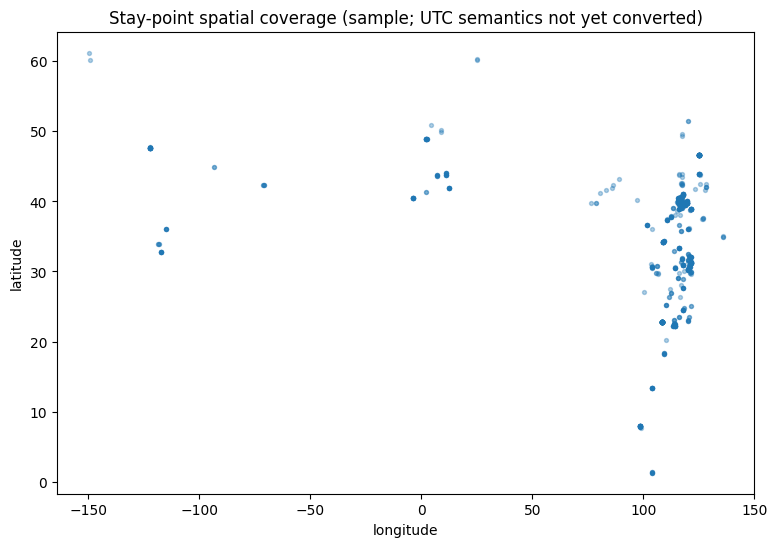

TIMEZONE POLICY STATUS: OPEN
Do not run Home/Office time-of-day scoring until this gate is reviewed.


In [5]:
spatial_summary = stays[["latitude", "longitude"]].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
)
display(spatial_summary)

user_centers = (
    stays.groupby("user_id")[["latitude", "longitude"]]
    .median()
    .rename(columns={"latitude":"median_latitude","longitude":"median_longitude"})
)
display(user_centers.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

sample_n = min(5000, len(stays))
plot_sample = stays.sample(sample_n, random_state=42) if sample_n else stays
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(plot_sample["longitude"], plot_sample["latitude"], s=8, alpha=0.35)
ax.set(
    title="Stay-point spatial coverage (sample; UTC semantics not yet converted)",
    xlabel="longitude",
    ylabel="latitude",
)
plt.show()

print("TIMEZONE POLICY STATUS: OPEN")
print("Do not run Home/Office time-of-day scoring until this gate is reviewed.")

### Kết quả

Phần lớn stay points tập trung rất rõ quanh Beijing:

```text
median latitude  ≈ 39.98
median longitude ≈ 116.33
````

User-level median locations cũng tập trung quanh cùng khu vực.

Tuy nhiên dataset vẫn có các stays nằm rất xa Beijing:

```text
latitude:   1.28 → 61.22
longitude: -149.88 → 135.77
```

Scatter plot cũng cho thấy ngoài cụm chính quanh Beijing vẫn có nhiều outliers/travel locations.

Vì vậy không nên áp `UTC+8` cho toàn bộ GeoLife.

**Decision:** trước khi dùng night/office-hour heuristic, cần chọn một Beijing-focused cohort; chỉ các stays trong region của những user đủ điều kiện mới được convert sang `Asia/Shanghai`.

```



### 4.1 Chọn nhóm user phù hợp với timezone Beijing

Phần trước cho thấy phần lớn dữ liệu tập trung quanh Beijing, nhưng vẫn có travel/outlier locations.

Vì vậy ta không gán `UTC+8` cho toàn bộ dataset ngay lập tức. Thay vào đó, ta kiểm tra mỗi user có thực sự chủ yếu hoạt động quanh Beijing hay không.

Ta dùng điểm tham chiếu:

```text
39.9042° N, 116.4074° E
````

để tính khoảng cách tới Beijing. Đây chỉ là **mốc để đo khoảng cách**, không phải ranh giới hành chính của thành phố.

Ta thử ba bán kính:

```text
50 km
100 km
200 km
```

Với mỗi user, tính hai tỷ lệ:

```text
stay_share_inside
= tỷ lệ số stays nằm trong vùng

dwell_share_inside
= tỷ lệ tổng thời gian dừng nằm trong vùng
```

Cần cả hai vì chỉ đếm số stays có thể gây hiểu nhầm.

Ví dụ:

```text
9 short stays ở Beijing
1 very long stay ở nơi khác
```

thì `stay_share_inside` có thể rất cao, nhưng `dwell_share_inside` lại thấp hơn nhiều.

Ta coi user là Beijing-focused khi cả hai tỷ lệ đều >=80%.


In [6]:
BEIJING_CENTER = (39.9042, 116.4074)

# Sensitivity candidates
BEIJING_RADII_KM = [50.0, 100.0, 200.0]
MIN_SHARE_VALUES = [0.50, 0.80, 0.90, 0.95]

# Frozen CP2 v1 candidate
CANDIDATE_RADIUS_KM = 100.0
CANDIDATE_MIN_STAY_SHARE = 0.80
CANDIDATE_MIN_DWELL_SHARE = 0.80


# -------------------------------------------------------------------
# 1. Distance của từng stay tới Beijing reference point
# -------------------------------------------------------------------

stays_geo = stays.copy()

stays_geo["distance_to_beijing_km"] = (
    np.asarray(
        haversine_m(
            stays_geo["latitude"].to_numpy(dtype=float),
            stays_geo["longitude"].to_numpy(dtype=float),
            BEIJING_CENTER[0],
            BEIJING_CENTER[1],
        ),
        dtype=float,
    )
    / 1000.0
)

print("Stay distance to Beijing reference point (km):")
display(
    stays_geo["distance_to_beijing_km"].describe(
        percentiles=[.5, .75, .9, .95, .99]
    )
)


# -------------------------------------------------------------------
# 2. Geography sensitivity:
#    radius × minimum stay/dwell share
# -------------------------------------------------------------------

total_users = stays_geo["user_id"].nunique()
total_stays = len(stays_geo)

radius_rows = []
user_geo_frames = {}

for radius_km in BEIJING_RADII_KM:
    inside = stays_geo["distance_to_beijing_km"] <= radius_km

    tmp = stays_geo.assign(
        inside_radius=inside,
        inside_dwell_s=np.where(
            inside,
            stays_geo["duration_s"],
            0.0,
        ),
    )

    by_user = (
        tmp.groupby("user_id")
        .agg(
            total_stays=("user_id", "size"),
            inside_stays=("inside_radius", "sum"),
            total_dwell_s=("duration_s", "sum"),
            inside_dwell_s=("inside_dwell_s", "sum"),
        )
    )

    by_user["stay_share_inside"] = (
        by_user["inside_stays"] / by_user["total_stays"]
    )

    by_user["dwell_share_inside"] = np.where(
        by_user["total_dwell_s"] > 0,
        by_user["inside_dwell_s"] / by_user["total_dwell_s"],
        0.0,
    )

    user_geo_frames[radius_km] = by_user

    for min_share in MIN_SHARE_VALUES:
        eligible = (
            (by_user["stay_share_inside"] >= min_share)
            & (by_user["dwell_share_inside"] >= min_share)
        )

        eligible_user_ids = by_user.index[eligible]

        eligible_user_mask = stays_geo["user_id"].isin(
            eligible_user_ids
        )

        in_region_eligible_mask = (
            eligible_user_mask
            & inside
        )

        eligible_users = int(eligible.sum())

        stays_from_eligible_users = int(
            eligible_user_mask.sum()
        )

        in_region_stays = int(
            in_region_eligible_mask.sum()
        )

        radius_rows.append(
            {
                "radius_km": radius_km,
                "min_both_shares": min_share,

                "eligible_users": eligible_users,
                "eligible_user_rate": (
                    eligible_users / total_users
                ),

                # Includes both in-region + travel stays
                # belonging to eligible users.
                "stays_from_eligible_users": (
                    stays_from_eligible_users
                ),
                "eligible_user_stay_rate": (
                    stays_from_eligible_users / total_stays
                ),

                # These are the stays that would actually be
                # allowed into Beijing semantic-time processing.
                "in_region_stays": in_region_stays,
                "in_region_stay_rate": (
                    in_region_stays / total_stays
                ),
            }
        )


radius_sensitivity = pd.DataFrame(radius_rows)

print("\nFull radius/share sensitivity:")

display(
    radius_sensitivity.style.format(
        {
            "radius_km": "{:.0f}",
            "min_both_shares": "{:.0%}",
            "eligible_user_rate": "{:.2%}",
            "eligible_user_stay_rate": "{:.2%}",
            "in_region_stay_rate": "{:.2%}",
        }
    )
)


# -------------------------------------------------------------------
# 3. Focused comparison tại frozen 80/80 share threshold
# -------------------------------------------------------------------

radius_80_80 = (
    radius_sensitivity[
        radius_sensitivity["min_both_shares"] == 0.80
    ]
    .copy()
    .reset_index(drop=True)
)

print("\nRadius comparison at 80% stay share + 80% dwell share:")

display(
    radius_80_80[
        [
            "radius_km",
            "eligible_users",
            "eligible_user_rate",
            "stays_from_eligible_users",
            "eligible_user_stay_rate",
            "in_region_stays",
            "in_region_stay_rate",
        ]
    ].style.format(
        {
            "radius_km": "{:.0f}",
            "eligible_user_rate": "{:.2%}",
            "eligible_user_stay_rate": "{:.2%}",
            "in_region_stay_rate": "{:.2%}",
        }
    )
)


# -------------------------------------------------------------------
# 4. Freeze candidate:
#    100 km + >=80% stay share + >=80% dwell share
# -------------------------------------------------------------------

candidate_geo = user_geo_frames[
    CANDIDATE_RADIUS_KM
].copy()

candidate_geo["beijing_candidate"] = (
    (
        candidate_geo["stay_share_inside"]
        >= CANDIDATE_MIN_STAY_SHARE
    )
    & (
        candidate_geo["dwell_share_inside"]
        >= CANDIDATE_MIN_DWELL_SHARE
    )
)

beijing_user_ids = candidate_geo.index[
    candidate_geo["beijing_candidate"]
]

candidate_user_mask = stays_geo["user_id"].isin(
    beijing_user_ids
)

inside_candidate_radius = (
    stays_geo["distance_to_beijing_km"]
    <= CANDIDATE_RADIUS_KM
)


# -------------------------------------------------------------------
# 5. Observation-level application
#
# User có thể đủ điều kiện Beijing-focused,
# nhưng các travel stays của chính user đó vẫn bị loại.
# -------------------------------------------------------------------

stays_beijing = stays_geo[
    candidate_user_mask
    & inside_candidate_radius
].copy()

excluded_travel_stays = stays_geo[
    candidate_user_mask
    & ~inside_candidate_radius
].copy()


# -------------------------------------------------------------------
# 6. Frozen candidate summary
# -------------------------------------------------------------------

candidate_user_rate = (
    len(beijing_user_ids) / total_users
)

candidate_semantic_stay_rate = (
    len(stays_beijing) / total_stays
)

candidate_all_user_stays = int(
    candidate_user_mask.sum()
)

candidate_all_user_stay_rate = (
    candidate_all_user_stays / total_stays
)

print("\nFrozen Beijing-focused candidate:")
print(
    "Policy:",
    f"{CANDIDATE_RADIUS_KM:.0f} km",
    f"+ stay_share >= {CANDIDATE_MIN_STAY_SHARE:.0%}",
    f"+ dwell_share >= {CANDIDATE_MIN_DWELL_SHARE:.0%}",
)

print(
    "Eligible users:",
    len(beijing_user_ids),
    f"/ {total_users}",
    f"({candidate_user_rate:.2%})",
)

print(
    "All stays belonging to eligible users:",
    candidate_all_user_stays,
    f"/ {total_stays}",
    f"({candidate_all_user_stay_rate:.2%})",
)

print(
    "In-region stays used for semantic-time processing:",
    len(stays_beijing),
    f"/ {total_stays}",
    f"({candidate_semantic_stay_rate:.2%})",
)

print(
    "Excluded travel/out-of-region stays from eligible users:",
    len(excluded_travel_stays),
)


# -------------------------------------------------------------------
# 7. Inspect strongest Beijing-focused users
# -------------------------------------------------------------------

display(
    candidate_geo[
        [
            "total_stays",
            "inside_stays",
            "stay_share_inside",
            "dwell_share_inside",
            "beijing_candidate",
        ]
    ]
    .sort_values(
        [
            "beijing_candidate",
            "stay_share_inside",
            "dwell_share_inside",
        ],
        ascending=[False, False, False],
    )
    .head(30)
)

Stay distance to Beijing reference point (km):


count     5821.000000
mean       367.611318
std       1374.856990
min          0.262611
50%         11.757089
75%         18.018798
90%        975.741561
95%       1976.108171
99%       8696.294665
max      10838.862247
Name: distance_to_beijing_km, dtype: float64


Full radius/share sensitivity:


,radius_km,min_both_shares,eligible_users,eligible_user_rate,stays_from_eligible_users,eligible_user_stay_rate,in_region_stays,in_region_stay_rate
0,50,50%,109,80.15%,5176,88.92%,4600,79.02%
1,50,80%,90,66.18%,4279,73.51%,3991,68.56%
2,50,90%,78,57.35%,2720,46.73%,2641,45.37%
3,50,95%,66,48.53%,2035,34.96%,2008,34.50%
4,100,50%,113,83.09%,5343,91.79%,4783,82.17%
5,100,80%,97,71.32%,4442,76.31%,4197,72.10%
6,100,90%,87,63.97%,3149,54.10%,3078,52.88%
7,100,95%,78,57.35%,2461,42.28%,2441,41.93%
8,200,50%,119,87.50%,5521,94.85%,4932,84.73%
9,200,80%,103,75.74%,4566,78.44%,4332,74.42%



Radius comparison at 80% stay share + 80% dwell share:


,radius_km,eligible_users,eligible_user_rate,stays_from_eligible_users,eligible_user_stay_rate,in_region_stays,in_region_stay_rate
0,50,90,66.18%,4279,73.51%,3991,68.56%
1,100,97,71.32%,4442,76.31%,4197,72.10%
2,200,103,75.74%,4566,78.44%,4332,74.42%



Frozen Beijing-focused candidate:
Policy: 100 km + stay_share >= 80% + dwell_share >= 80%
Eligible users: 97 / 136 (71.32%)
All stays belonging to eligible users: 4442 / 5821 (76.31%)
In-region stays used for semantic-time processing: 4197 / 5821 (72.10%)
Excluded travel/out-of-region stays from eligible users: 245


,total_stays,inside_stays,stay_share_inside,dwell_share_inside,beijing_candidate
user_id,,,,,
001,32,32,1.0,1.0,True
007,46,46,1.0,1.0,True
008,30,30,1.0,1.0,True
009,74,74,1.0,1.0,True
011,2,2,1.0,1.0,True
014,12,12,1.0,1.0,True
015,32,32,1.0,1.0,True
016,25,25,1.0,1.0,True
017,79,79,1.0,1.0,True


### Vì sao chọn 100 km?

Ở cùng điều kiện `>=80% stays` và `>=80% dwell time` nằm trong vùng:

- `50 km` giữ **90/136 users (66.18%)**;
- `100 km` giữ **97/136 users (71.32%)**;
- `200 km` giữ **103/136 users (75.74%)**.

Tăng từ `50 → 100 km` thêm 7 users, trong khi `100 → 200 km` chỉ thêm 6 users nhưng geography được mở rộng gấp đôi.

Không có Home/Office ground truth để tối ưu radius theo accuracy, nên `100 km` được chọn như một **middle engineering baseline**: ít chặt hơn 50 km nhưng không mở rộng tới 200 km chỉ để lấy thêm một lượng coverage tương đối nhỏ.

Với policy `100 km + 80/80%`, có **97 users** đủ điều kiện. Sau khi loại riêng các travel/out-of-region stays của họ, còn **4,197 stays (72.10%)** được dùng cho semantic-time processing.

### Kết luận geography gate

Với policy đã chọn:

```text
radius = 100 km
stay_share_inside >= 80%
dwell_share_inside >= 80%
````

ta có:

* **97 users** đủ điều kiện để xử lý theo timezone Beijing;
* **4,197 stays** nằm trong region và được dùng cho Home/Office semantics;
* **245 stays** của các user đủ điều kiện nhưng nằm ngoài region nên bị loại;
* tổng số semantic stays giữ lại chiếm **72.10%** của toàn bộ 5,821 stays.

Điểm quan trọng là geography gate hoạt động ở **hai mức**:

```text
user-level
→ quyết định user có phải Beijing-focused hay không

stay-level
→ chỉ giữ những stays thực sự nằm trong Beijing region
```

Ví dụ một user có 90% activity ở Beijing nhưng có vài stays khi đi travel thì user đó vẫn được giữ, nhưng các travel stays sẽ không được convert sang `Asia/Shanghai` để tính Home/Office.

Users không đủ điều kiện Beijing-focused sẽ **abstain** trong CP2 v1 thay vì cố đoán timezone từ longitude.

**Decision:** chỉ áp behavioral local time cho in-region stays của Beijing-focused users.

```
```


### 4.2 Chuyển UTC sang giờ địa phương cho Beijing cohort

Sau geography gate, chỉ **4,197 in-region stays** của Beijing-focused users mới được dùng cho Home/Office inference.

Timestamp trong GeoLife đang ở UTC, nên trước khi xác định:

```text
ban đêm → HOME
giờ hành chính → OFFICE
````

ta phải chuyển chúng sang giờ địa phương của Beijing:

```text
UTC
 ↓
Asia/Shanghai
 ↓
local date / hour / weekday
```

Notebook dùng timezone-aware conversion:

```python
tz_convert("Asia/Shanghai")
```

thay vì cộng thủ công `+8 giờ`.

Lý do là timestamp sau khi convert vẫn giữ rõ thông tin timezone, giúp các bước xử lý thời gian phía sau nhất quán và dễ kiểm tra hơn.

Từ bước này, các field như:

* `arrival_local_date`
* `arrival_local_hour`
* `arrival_local_weekday`

mới được phép dùng để tính Home/Office behavioral features.

**Decision:** chỉ áp `Asia/Shanghai` cho 4,197 stays đã qua geography gate; các travel/out-of-region stays không được đưa vào heuristic theo giờ.



In [7]:
BEIJING_TZ = ZoneInfo("Asia/Shanghai")

stays_beijing["arrival_time_local"] = (
    stays_beijing["arrival_time_utc"].dt.tz_convert(BEIJING_TZ)
)
stays_beijing["departure_time_local"] = (
    stays_beijing["departure_time_utc"].dt.tz_convert(BEIJING_TZ)
)
stays_beijing["arrival_local_date"] = stays_beijing["arrival_time_local"].dt.date
stays_beijing["arrival_local_hour"] = stays_beijing["arrival_time_local"].dt.hour
stays_beijing["arrival_local_weekday"] = (
    stays_beijing["arrival_time_local"].dt.weekday
)

print("Timezone:", BEIJING_TZ)
print("Users in candidate cohort:", stays_beijing["user_id"].nunique())
print("Stays in candidate cohort:", len(stays_beijing))

display(
    stays_beijing[
        [
            "user_id",
            "arrival_time_utc",
            "arrival_time_local",
            "departure_time_local",
            "duration_s",
        ]
    ].head(10)
)

display(
    stays_beijing["arrival_local_hour"]
    .value_counts()
    .sort_index()
    .rename("stays")
    .to_frame()
)

print("TIMEZONE POLICY STATUS: candidate Beijing cohort ready for review")
print("Home/Office scoring remains gated until geography sensitivity is reviewed.")

Timezone: Asia/Shanghai
Users in candidate cohort: 97
Stays in candidate cohort: 4197


,stays
arrival_local_hour,
0,119
1,121
2,115
3,85
4,97
5,75
6,100
7,105
8,176


TIMEZONE POLICY STATUS: candidate Beijing cohort ready for review
Home/Office scoring remains gated until geography sensitivity is reviewed.


Exact user-level UTC/local timestamp sample omitted from committed notebook for privacy.


### 4.3 DBSCAN `eps` sensitivity trên cùng Beijing cohort

Prototype đầu tiên chỉ thử:

```text
eps = 200 m
```

và thấy chaining khá rõ.

Để kiểm tra công bằng hơn, ta thử thêm:

```text
eps = 10 / 20 / 30 / 50 / 100 / 150 / 200 m
```

trên **cùng 4,197 Beijing semantic stays** sẽ được dùng cho complete-link ở phần sau.

Với mỗi `eps`, ta đo:

- `locations`: tổng số clusters;
- `recurring_locations`: clusters có >=2 stays;
- `users_with_recurring_location`: user có ít nhất một recurring location;
- `median_locations_per_user`: số locations điển hình mỗi user;
- `median_recurring_diameter_m`;
- `p95_recurring_diameter_m`;
- `max_recurring_diameter_m`;
- `recurring_clusters_le_200_rate`;
- `recurring_clusters_gt_200`.

Ở đây:

```text
eps
→ khoảng cách kết nối cục bộ của DBSCAN

diameter
→ khoảng cách lớn nhất giữa hai stays trong toàn cluster
```

Ta muốn xem trade-off:

```text
eps nhỏ
→ cluster compact hơn?
→ nhưng có bị split location và giảm coverage không?

eps lớn
→ coverage tăng?
→ nhưng chaining tăng đến mức nào?
```


In [8]:
DBSCAN_EPS_VALUES_M = [10.0, 20.0, 30.0, 50.0, 100.0, 150.0, 200.0]

def summarize_dbscan_eps(stays_input, eps_m):
    location_rows = []

    for user_id, group in stays_input.groupby("user_id", sort=True):
        g = group.sort_values("arrival_time_local", kind="stable").copy()

        lat = g["latitude"].to_numpy(dtype=float)
        lon = g["longitude"].to_numpy(dtype=float)

        coords_rad = np.radians(
            g[["latitude", "longitude"]].to_numpy(dtype=float)
        )

        labels = DBSCAN(
            eps=eps_m / EARTH_RADIUS_M,
            min_samples=1,
            metric="haversine",
            algorithm="ball_tree",
        ).fit_predict(coords_rad)

        distances = np.asarray(
            haversine_m(
                lat[:, None],
                lon[:, None],
                lat[None, :],
                lon[None, :],
            ),
            dtype=float,
        )

        for location_id in np.unique(labels):
            member_idx = np.flatnonzero(labels == location_id)
            members = g.iloc[member_idx]

            diameter_m = (
                float(distances[np.ix_(member_idx, member_idx)].max())
                if len(member_idx) > 1
                else 0.0
            )

            location_rows.append({
                "user_id": user_id,
                "location_id": int(location_id),
                "stay_count": len(member_idx),
                "active_local_dates": members["arrival_local_date"].nunique(),
                "total_dwell_h": members["duration_s"].sum() / 3600.0,
                "diameter_m": diameter_m,
            })

    locations_eps = pd.DataFrame(location_rows)
    recurring = locations_eps["stay_count"] >= 2
    recurring_locations = locations_eps.loc[recurring].copy()

    summary = {
        "eps_m": eps_m,
        "locations": len(locations_eps),
        "recurring_locations": int(recurring.sum()),
        "users_with_recurring_location": int(
            recurring_locations["user_id"].nunique()
        ),
        "median_locations_per_user": float(
            locations_eps.groupby("user_id").size().median()
        ),
        "median_recurring_diameter_m": float(
            recurring_locations["diameter_m"].median()
        ) if len(recurring_locations) else np.nan,
        "p95_recurring_diameter_m": float(
            recurring_locations["diameter_m"].quantile(0.95)
        ) if len(recurring_locations) else np.nan,
        "max_recurring_diameter_m": float(
            recurring_locations["diameter_m"].max()
        ) if len(recurring_locations) else np.nan,
        "recurring_clusters_le_200_rate": float(
            (recurring_locations["diameter_m"] <= 200.0).mean()
        ) if len(recurring_locations) else np.nan,
        "recurring_clusters_gt_200": int(
            (recurring_locations["diameter_m"] > 200.0).sum()
        ) if len(recurring_locations) else 0,
    }

    return locations_eps, summary


dbscan_sensitivity_rows = []
dbscan_artifacts = {}

for eps_m in DBSCAN_EPS_VALUES_M:
    locations_eps, summary = summarize_dbscan_eps(
        stays_beijing,
        eps_m,
    )
    dbscan_artifacts[eps_m] = locations_eps
    dbscan_sensitivity_rows.append(summary)

dbscan_eps_sensitivity = pd.DataFrame(dbscan_sensitivity_rows)

display(
    dbscan_eps_sensitivity[
        [
            "eps_m",
            "locations",
            "recurring_locations",
            "users_with_recurring_location",
            "median_locations_per_user",
            "median_recurring_diameter_m",
            "p95_recurring_diameter_m",
            "max_recurring_diameter_m",
            "recurring_clusters_le_200_rate",
            "recurring_clusters_gt_200",
        ]
    ]
)


,eps_m,locations,recurring_locations,users_with_recurring_location,median_locations_per_user,median_recurring_diameter_m,p95_recurring_diameter_m,max_recurring_diameter_m,recurring_clusters_le_200_rate,recurring_clusters_gt_200
0,10.0,2359,322,59,15.0,8.570764,51.811808,110.839406,1.000000,0
1,20.0,1825,334,63,11.0,16.067361,79.878614,172.311466,1.000000,0
2,30.0,1593,354,65,10.0,24.735450,106.310482,181.317738,1.000000,0
3,50.0,1384,381,67,9.0,35.562999,122.126394,248.799549,0.986877,5
4,100.0,1185,408,67,8.0,54.068398,193.123356,441.314238,0.953431,19
5,150.0,1082,417,71,7.0,68.145156,292.695456,627.111121,0.901679,41
6,200.0,1003,418,73,6.0,74.751270,365.006984,836.663078,0.837321,68


### Kết quả DBSCAN sensitivity

Kết quả cho thấy trade-off khá rõ:
```text
| eps | recurring users | p95 diameter | max diameter | clusters >200m |
|---:|---:|---:|---:|---:|
| 10 m | 59 | 51.8 m | 110.8 m | 0 |
| 20 m | 63 | 79.9 m | 172.3 m | 0 |
| 30 m | 65 | 106.3 m | 181.3 m | 0 |
| 50 m | 67 | 122.1 m | 248.8 m | 5 |
| 100 m | 67 | 193.1 m | 441.3 m | 19 |
| 150 m | 71 | 292.7 m | 627.1 m | 41 |
| 200 m | 73 | 365.0 m | 836.7 m | 68 |
```
### Khi `eps` rất nhỏ

`eps=10–30 m` cho cluster rất compact trên dataset này: không có recurring cluster nào vượt 200 m.

Nhưng coverage giảm:

```text
59 → 63 → 65 recurring users
```

và số locations tăng mạnh. Ví dụ `eps=10 m` tạo 2,359 locations, median 15 locations/user.

Điều này cho thấy `eps` quá nhỏ có thể **fragment** một semantic place thành nhiều cluster nhỏ.

### Khi `eps` tăng

Coverage tăng dần lên 73 recurring users, nhưng chaining cũng tăng:

```text
eps=200 m
→ 68 recurring clusters >200 m
→ max diameter ≈ 837 m
```

Vì vậy DBSCAN **vẫn là một candidate hợp lý để benchmark**, chứ không phải một phương pháp sai.

Nhưng sensitivity cũng cho thấy không có một `eps` rõ ràng vừa giữ coverage cao, vừa tránh fragmentation, vừa cho hard diameter contract.

Lưu ý: việc `eps=10–30 m` hiện quan sát được tất cả cluster <=200 m là **empirical result trên dataset này**, không phải guarantee của DBSCAN.


### 4.4 Complete-link recurring-location audit

DBSCAN sensitivity ở trên cho thấy:

```text
eps nhỏ → compact hơn nhưng coverage giảm
eps lớn → coverage tăng nhưng chaining tăng
```

Bây giờ ta thử một representation khác: **complete-link agglomerative clustering**.

Với complete-link, threshold có ý nghĩa trực tiếp hơn:

```text
threshold = 200 m
→ maximum pairwise distance trong cluster <= 200 m
```


In [9]:
COMPLETE_LINK_THRESHOLDS_M = [100.0, 200.0, 300.0]
CANDIDATE_COMPLETE_LINK_M = 200.0

def pairwise_haversine_matrix_m(group):
    lat = group["latitude"].to_numpy(dtype=float)
    lon = group["longitude"].to_numpy(dtype=float)
    return np.asarray(
        haversine_m(
            lat[:, None],
            lon[:, None],
            lat[None, :],
            lon[None, :],
        ),
        dtype=float,
    )

def complete_link_user(group, threshold_m):
    g = group.sort_values("arrival_time_local", kind="stable").copy()
    n = len(g)
    if n == 1:
        g["location_id"] = 0
        return g, np.zeros((1, 1), dtype=float)

    distances = pairwise_haversine_matrix_m(g)
    labels = AgglomerativeClustering(
        n_clusters=None,
        metric="precomputed",
        linkage="complete",
        distance_threshold=threshold_m,
    ).fit_predict(distances)
    g["location_id"] = labels.astype(int)
    return g, distances

def summarize_complete_link(threshold_m):
    clustered_parts = []
    location_rows = []

    for user_id, group in stays_beijing.groupby("user_id", sort=True):
        clustered_user, distances = complete_link_user(group, threshold_m)
        clustered_parts.append(clustered_user)

        labels = clustered_user["location_id"].to_numpy(dtype=int)
        for location_id in np.unique(labels):
            member_idx = np.flatnonzero(labels == location_id)
            members = clustered_user.iloc[member_idx]
            diameter_m = (
                float(distances[np.ix_(member_idx, member_idx)].max())
                if len(member_idx) > 1
                else 0.0
            )
            location_rows.append({
                "user_id": user_id,
                "location_id": int(location_id),
                "latitude": float(members["latitude"].median()),
                "longitude": float(members["longitude"].median()),
                "stay_count": len(members),
                "active_local_dates": members["arrival_local_date"].nunique(),
                "total_dwell_h": members["duration_s"].sum() / 3600.0,
                "diameter_m": diameter_m,
            })

    clustered_all = pd.concat(clustered_parts, ignore_index=True)
    locations_all = pd.DataFrame(location_rows)

    recurring = locations_all["stay_count"] >= 2
    return clustered_all, locations_all, {
        "threshold_m": threshold_m,
        "locations": len(locations_all),
        "recurring_locations": int(recurring.sum()),
        "users_with_recurring_location": int(
            locations_all.loc[recurring, "user_id"].nunique()
        ),
        "median_locations_per_user": float(
            locations_all.groupby("user_id").size().median()
        ),
        "p95_diameter_m": float(locations_all["diameter_m"].quantile(0.95)),
        "max_diameter_m": float(locations_all["diameter_m"].max()),
    }

cluster_sensitivity_rows = []
cluster_artifacts = {}

for threshold_m in COMPLETE_LINK_THRESHOLDS_M:
    clustered_threshold, locations_threshold, summary = summarize_complete_link(
        threshold_m
    )
    cluster_sensitivity_rows.append(summary)
    cluster_artifacts[threshold_m] = (
        clustered_threshold,
        locations_threshold,
    )

complete_link_sensitivity = pd.DataFrame(cluster_sensitivity_rows)
display(complete_link_sensitivity)

semantic_stays, semantic_locations = cluster_artifacts[CANDIDATE_COMPLETE_LINK_M]

assert semantic_locations["diameter_m"].max() <= CANDIDATE_COMPLETE_LINK_M + 1e-6

print("Candidate complete-link threshold:", CANDIDATE_COMPLETE_LINK_M, "m")
print("Semantic locations:", len(semantic_locations))
print(
    "Recurring semantic locations (>=2 stays):",
    int((semantic_locations["stay_count"] >= 2).sum()),
)
print(
    "Users with recurring semantic location:",
    semantic_locations.loc[
        semantic_locations["stay_count"] >= 2, "user_id"
    ].nunique(),
)
print(
    "Max verified cluster diameter (m):",
    semantic_locations["diameter_m"].max(),
)

display(
    semantic_locations.sort_values(
        ["stay_count", "total_dwell_h"],
        ascending=False,
    ).head(30)
)

,threshold_m,locations,recurring_locations,users_with_recurring_location,median_locations_per_user,p95_diameter_m,max_diameter_m
0,100.0,1320,499,67,9.0,83.264292,99.953318
1,200.0,1111,486,73,7.0,159.686875,199.233480
2,300.0,1007,473,73,6.0,247.457965,297.415977


Candidate complete-link threshold: 200.0 m
Semantic locations: 1111
Recurring semantic locations (>=2 stays): 486
Users with recurring semantic location: 73
Max verified cluster diameter (m): 199.23348019699617


Exact user-level semantic-location coordinates omitted from committed notebook for privacy.


### Diễn giải kết quả complete-link

Khi tăng threshold, các stays gần nhau được merge thành location lớn hơn:
```text
| threshold | recurring users | recurring locations | max diameter |
|---:|---:|---:|---:|
| 100 m | 67 | 499 | 99.95 m |
| **200 m** | **73** | **486** | **199.23 m** |
| 300 m | 73 | 473 | 297.42 m |
```
Điểm đáng chú ý:

```text
100 → 200 m
67 → 73 recurring users

200 → 300 m
73 → 73 recurring users
````

Tức là tăng từ `100m` lên `200m` giúp giữ thêm recurring-user coverage, nhưng tăng tiếp lên `300m` không thêm user mới mà chỉ merge các locations rộng hơn.

Vì vậy chọn **complete-link 200 m** làm production baseline:

* giữ được **73 users có recurring location**;
* tạo **486 recurring locations**;
* vẫn đảm bảo mọi cluster có diameter không vượt quá `200m`;
* max diameter quan sát được là khoảng **199.23m**.

**Decision:** `200m` là mức cân bằng giữa coverage và độ compact của location; `300m` không đem lại thêm recurring-user coverage.



### 4.5 So sánh DBSCAN và complete-link

Sau khi audit riêng DBSCAN và complete-link, ta đặt hai phương pháp lên **cùng một bảng** để so sánh trực tiếp.

Với DBSCAN, chọn ba mức đại diện từ sensitivity phía trên:

```text
eps = 30 m
→ ưu tiên cluster compact

eps = 100 m
→ mức trung gian

eps = 200 m
→ ưu tiên recurring-user coverage
````

So với production candidate:

```text
complete-link threshold = 200 m
```

Các phương pháp được so trên cùng Beijing cohort và cùng các metrics:

* tổng số locations;
* số recurring locations (`>=2 stays`);
* số users có recurring location;
* `p95` cluster diameter;
* maximum cluster diameter;
* tỷ lệ recurring clusters có diameter `<=200 m`.

GeoLife không có Home/Office ground truth, nên bảng này **không đo accuracy**.
Mục tiêu là xem mỗi cách clustering cân bằng thế nào giữa **coverage** và **độ gọn của location**.

````


In [10]:
dbscan_compare = (
    dbscan_eps_sensitivity[
        dbscan_eps_sensitivity["eps_m"].isin([30.0, 100.0, 200.0])
    ][
        [
            "eps_m",
            "locations",
            "recurring_locations",
            "users_with_recurring_location",
            "p95_recurring_diameter_m",
            "max_recurring_diameter_m",
            "recurring_clusters_le_200_rate",
        ]
    ]
    .copy()
)

dbscan_compare["method"] = "DBSCAN"
dbscan_compare["setting_m"] = dbscan_compare["eps_m"]
dbscan_compare = dbscan_compare.rename(
    columns={
        "p95_recurring_diameter_m": "p95_diameter_m",
        "max_recurring_diameter_m": "max_diameter_m",
        "recurring_clusters_le_200_rate": "clusters_le_200_rate",
    }
)

complete_compare = complete_link_sensitivity[
    complete_link_sensitivity["threshold_m"] == CANDIDATE_COMPLETE_LINK_M
].copy()

complete_compare["method"] = "complete-link"
complete_compare["setting_m"] = complete_compare["threshold_m"]
complete_compare["clusters_le_200_rate"] = (
    complete_compare["max_diameter_m"] <= CANDIDATE_COMPLETE_LINK_M + 1e-6
).astype(float)

clustering_benchmark = pd.concat(
    [
        dbscan_compare[
            [
                "method",
                "setting_m",
                "locations",
                "recurring_locations",
                "users_with_recurring_location",
                "p95_diameter_m",
                "max_diameter_m",
                "clusters_le_200_rate",
            ]
        ],
        complete_compare[
            [
                "method",
                "setting_m",
                "locations",
                "recurring_locations",
                "users_with_recurring_location",
                "p95_diameter_m",
                "max_diameter_m",
                "clusters_le_200_rate",
            ]
        ],
    ],
    ignore_index=True,
)

display(clustering_benchmark)


,method,setting_m,locations,recurring_locations,users_with_recurring_location,p95_diameter_m,max_diameter_m,clusters_le_200_rate
0,DBSCAN,30.0,1593,354,65,106.310482,181.317738,1.000000
1,DBSCAN,100.0,1185,408,67,193.123356,441.314238,0.953431
2,DBSCAN,200.0,1003,418,73,365.006984,836.663078,0.837321
3,complete-link,200.0,1111,486,73,159.686875,199.233480,1.000000


### Kết quả benchmark

Bảng trên cho thấy trade-off giữa **recurring-user coverage** và **độ gọn của cluster**.

- `DBSCAN 30 m` tạo cluster rất gọn: **100% recurring clusters <=200 m**, nhưng chỉ có **65 users** có recurring location.
- `DBSCAN 100 m` tăng lên **67 users**, nhưng bắt đầu có chaining: chỉ còn **95.34%** recurring clusters nằm trong 200 m và max diameter tăng lên khoảng **441 m**.
- `DBSCAN 200 m` đạt **73 users**, nhưng cluster rộng hơn rõ rệt: chỉ **83.73%** recurring clusters nằm trong 200 m, max diameter khoảng **837 m**.
- `complete-link 200 m` cũng đạt **73 users**, nhưng **100% clusters <=200 m** và max diameter chỉ khoảng **199 m**.

So sánh trực tiếp ở cùng mức coverage cao nhất:

```text
DBSCAN 200 m
→ 73 recurring users
→ max diameter ≈ 837 m
→ 83.73% recurring clusters <= 200 m

complete-link 200 m
→ 73 recurring users
→ max diameter ≈ 199 m
→ 100% clusters <= 200 m
````

### Decision

DBSCAN vẫn được giữ làm **benchmark model** theo yêu cầu Track B1.

Production CP2 v1 chọn **complete-link 200 m** vì trong audit này nó giữ được cùng **73 recurring users** như DBSCAN `eps=200 m`, nhưng cluster luôn nằm trong giới hạn `200 m`.

Điều này không có nghĩa DBSCAN sai hoặc accuracy thấp hơn; đây chỉ là lựa chọn engineering dựa trên **coverage + spatial compactness** khi chưa có Home/Office ground truth.



## 5. Frozen CP2 v1 semantic configuration

Đến đây, hai cách clustering có vai trò khác nhau:

```text
DBSCAN
→ benchmark / comparison theo yêu cầu Track B1

complete-link 200 m
→ clustering mặc định của CP2 v1
````

Sau khi có recurring locations, model mới dùng **behavior theo giờ địa phương** để quyết định HOME / OFFICE.

### HOME

```text
window:       21:00–06:00
min dates:    3
min share:    0.50
min margin:   0.20
```

Ý nghĩa:

* `min dates = 3`: location phải có HOME evidence trên ít nhất **3 ngày khác nhau**, tránh kết luận chỉ từ 1–2 lần xuất hiện.
* `min share = 0.50`: location đứng đầu phải chiếm ít nhất **50% HOME evidence** của user.
* `min margin = 0.20`: share của location đứng đầu phải cao hơn location thứ hai ít nhất **20 percentage points**, để tránh trường hợp hai nơi gần như ngang nhau.

### OFFICE

```text
window:       Mon–Fri 09:00–17:00
min dates:    3
min share:    0.30
min margin:   0.10
```

Cách đọc tương tự:

* phải có evidence trên ít nhất **3 ngày làm việc**;
* location đứng đầu phải chiếm ít nhất **30% OFFICE evidence**;
* phải hơn location đứng thứ hai ít nhất **10 percentage points**.

Ví dụ:

```text
top OFFICE share    = 0.45
second OFFICE share = 0.28

margin = 0.45 - 0.28 = 0.17
```

→ vượt `min share = 0.30` và `min margin = 0.10`.

### Support saturation = 5 relevant dates

Số ngày có evidence cũng được dùng để tăng `evidence_strength`:

```text
support = min(relevant_dates / 5, 1)
```

Ví dụ:

```text
1 ngày  → support = 0.20
3 ngày  → support = 0.60
5 ngày  → support = 1.00
8 ngày  → support vẫn = 1.00
```

Tức là evidence từ nhiều ngày đáng tin hơn, nhưng sau **5 ngày** thì không tiếp tục tăng điểm chỉ vì user có thêm dữ liệu.

HOME và OFFICE dùng threshold khác nhau vì distribution evidence quan sát được của hai loại location không giống nhau.

Nếu không vượt đủ các gate trên, model sẽ **abstain** thay vì cố gán nhãn.



In [11]:
CP2_V1_CONFIG = {
    "timezone": "Asia/Shanghai",
    "beijing_reference_lat": BEIJING_CENTER[0],
    "beijing_reference_lon": BEIJING_CENTER[1],
    "beijing_radius_km": CANDIDATE_RADIUS_KM,
    "beijing_min_stay_share": CANDIDATE_MIN_STAY_SHARE,
    "beijing_min_dwell_share": CANDIDATE_MIN_DWELL_SHARE,
    "home_night_start_hour": 21,
    "home_night_end_hour": 6,
    "office_start_hour": 9,
    "office_end_hour": 17,
    "office_weekdays": [0, 1, 2, 3, 4],
    "clustering_method": "complete_link",
    "candidate_location_complete_link_m": CANDIDATE_COMPLETE_LINK_M,
    "home_min_dates": 3,
    "home_min_share": 0.50,
    "home_min_margin": 0.20,
    "office_min_dates": 3,
    "office_min_share": 0.30,
    "office_min_margin": 0.10,
    "support_saturation_dates": 5,
}

display(pd.Series(CP2_V1_CONFIG, name="frozen_value"))
print("STATUS: CP2 v1 engineering baseline frozen; production parity check remains.")


timezone                                Asia/Shanghai
beijing_reference_lat                         39.9042
beijing_reference_lon                        116.4074
beijing_radius_km                               100.0
beijing_min_stay_share                            0.8
beijing_min_dwell_share                           0.8
home_night_start_hour                              21
home_night_end_hour                                 6
office_start_hour                                   9
office_end_hour                                    17
office_weekdays                       [0, 1, 2, 3, 4]
clustering_method                       complete_link
candidate_location_complete_link_m              200.0
home_min_dates                                      3
home_min_share                                    0.5
home_min_margin                                   0.2
office_min_dates                                    3
office_min_share                                  0.3
office_min_margin           

STATUS: CP2 v1 engineering baseline frozen; production parity check remains.


## 6. Home / Office scoring audit

### Vì sao không chỉ nhìn `arrival hour`?

Một stay có thể kéo dài qua ranh giới thời gian.

Ví dụ:

```text
20:50 ───────── 21:30
         21:00 bắt đầu HOME window
````

Trong trường hợp này chỉ có **30 phút từ 21:00–21:30** là HOME evidence.

Nếu chỉ nhìn giờ đến `20:50`, ta sẽ bỏ mất phần evidence đó.
Nếu chỉ nhìn giờ rời đi rồi gán cả stay là HOME, ta lại tính dư 10 phút.

Vì vậy notebook tính **phần thời gian thực sự overlap với HOME/OFFICE window**.

### Mỗi recurring location được chấm bằng những evidence nào?

Với mỗi location, ta đo:

* tổng thời gian nằm trong HOME hoặc OFFICE window;
* tỷ lệ thời gian đó so với toàn bộ semantic dwell của user;
* số ngày khác nhau có ít nhất **10 phút overlap**;
* khoảng cách giữa location đứng đầu và đứng thứ hai (`margin`).

`share` = evidence của location / tổng semantic dwell của user.

Tổng này bao gồm **mọi semantic locations**, không chỉ recurring candidates, để tránh làm `share` bị phóng đại.

Nhờ vậy, nếu user có nhiều dwell rải rác ở các location nhỏ khác, phần evidence đó vẫn được tính vào tổng và không bị “biến mất”.

### HOME và OFFICE có bắt buộc là hai nơi khác nhau không?

Không.

Nếu cùng một location vừa đứng đầu về night evidence, vừa đứng đầu về weekday daytime evidence, notebook vẫn giữ kết quả đó thay vì cố tạo ra một location thứ hai.

Trường hợp này được xem là **ambiguous but valid evidence**, và sẽ được report để audit.



In [12]:
HOME_NIGHT_START_HOUR = 21
HOME_NIGHT_END_HOUR = 6
OFFICE_START_HOUR = 9
OFFICE_END_HOUR = 17
OFFICE_WEEKDAYS = {0, 1, 2, 3, 4}

MIN_RELEVANT_DATE_OVERLAP_S = 10 * 60
MIN_RELEVANT_DATES = 2

def interval_overlap_s(start, end, window_start, window_end):
    overlap_start = max(start, window_start)
    overlap_end = min(end, window_end)
    if overlap_end <= overlap_start:
        return 0.0
    return float((overlap_end - overlap_start).total_seconds())

def stay_window_contributions(row):
    start = row.arrival_time_local
    end = row.departure_time_local

    night_rows = []
    office_rows = []

    # A stay shortly after midnight can overlap the night window that started
    # on the previous local date, so include one padded date before arrival.
    day = start.normalize() - pd.Timedelta(days=1)
    last_day = end.normalize()

    while day <= last_day:
        night_start = day + pd.Timedelta(hours=HOME_NIGHT_START_HOUR)
        night_end = day + pd.Timedelta(days=1, hours=HOME_NIGHT_END_HOUR)
        night_s = interval_overlap_s(start, end, night_start, night_end)
        if night_s > 0:
            night_rows.append(
                {
                    "user_id": row.user_id,
                    "location_id": int(row.location_id),
                    "behavior_date": night_start.date(),
                    "overlap_s": night_s,
                }
            )

        if day.weekday() in OFFICE_WEEKDAYS:
            office_start = day + pd.Timedelta(hours=OFFICE_START_HOUR)
            office_end = day + pd.Timedelta(hours=OFFICE_END_HOUR)
            office_s = interval_overlap_s(start, end, office_start, office_end)
            if office_s > 0:
                office_rows.append(
                    {
                        "user_id": row.user_id,
                        "location_id": int(row.location_id),
                        "behavior_date": office_start.date(),
                        "overlap_s": office_s,
                    }
                )

        day += pd.Timedelta(days=1)

    return night_rows, office_rows

night_rows = []
office_rows = []

for row in semantic_stays.itertuples(index=False):
    nr, orows = stay_window_contributions(row)
    night_rows.extend(nr)
    office_rows.extend(orows)

night_contrib = pd.DataFrame(
    night_rows,
    columns=["user_id", "location_id", "behavior_date", "overlap_s"],
)
office_contrib = pd.DataFrame(
    office_rows,
    columns=["user_id", "location_id", "behavior_date", "overlap_s"],
)

def aggregate_relevant_window(contrib, prefix):
    if contrib.empty:
        return pd.DataFrame(
            columns=[
                "user_id",
                "location_id",
                f"{prefix}_dwell_s",
                f"{prefix}_dates",
            ]
        )

    per_date = (
        contrib.groupby(["user_id", "location_id", "behavior_date"], as_index=False)
        ["overlap_s"]
        .sum()
    )

    dwell = (
        per_date.groupby(["user_id", "location_id"], as_index=False)["overlap_s"]
        .sum()
        .rename(columns={"overlap_s": f"{prefix}_dwell_s"})
    )

    supported_dates = (
        per_date.loc[per_date["overlap_s"] >= MIN_RELEVANT_DATE_OVERLAP_S]
        .groupby(["user_id", "location_id"], as_index=False)["behavior_date"]
        .nunique()
        .rename(columns={"behavior_date": f"{prefix}_dates"})
    )

    return dwell.merge(
        supported_dates,
        on=["user_id", "location_id"],
        how="left",
    ).fillna({f"{prefix}_dates": 0})

night_features = aggregate_relevant_window(night_contrib, "night")
office_features = aggregate_relevant_window(office_contrib, "office")

semantic_features = (
    semantic_locations.merge(
        night_features,
        on=["user_id", "location_id"],
        how="left",
    )
    .merge(
        office_features,
        on=["user_id", "location_id"],
        how="left",
    )
)

for col in ["night_dwell_s", "night_dates", "office_dwell_s", "office_dates"]:
    semantic_features[col] = semantic_features[col].fillna(0)

semantic_features["night_dates"] = semantic_features["night_dates"].astype(int)
semantic_features["office_dates"] = semantic_features["office_dates"].astype(int)

user_night_total = semantic_features.groupby("user_id")["night_dwell_s"].transform("sum")
user_office_total = semantic_features.groupby("user_id")["office_dwell_s"].transform("sum")

semantic_features["night_dwell_share"] = np.where(
    user_night_total > 0,
    semantic_features["night_dwell_s"] / user_night_total,
    0.0,
)
semantic_features["office_dwell_share"] = np.where(
    user_office_total > 0,
    semantic_features["office_dwell_s"] / user_office_total,
    0.0,
)

semantic_features["night_dwell_h"] = semantic_features["night_dwell_s"] / 3600.0
semantic_features["office_dwell_h"] = semantic_features["office_dwell_s"] / 3600.0

def rank_semantic_candidates(
    features,
    *,
    share_col,
    dates_col,
    dwell_col,
    label,
):
    eligible = features[
        (features["stay_count"] >= 2)
        & (features[dates_col] >= MIN_RELEVANT_DATES)
        & (features[dwell_col] > 0)
    ].copy()

    if eligible.empty:
        return eligible

    eligible = eligible.sort_values(
        ["user_id", share_col, dates_col, dwell_col, "stay_count"],
        ascending=[True, False, False, False, False],
        kind="stable",
    )
    eligible[f"{label}_rank"] = eligible.groupby("user_id").cumcount() + 1
    return eligible

home_ranked = rank_semantic_candidates(
    semantic_features,
    share_col="night_dwell_share",
    dates_col="night_dates",
    dwell_col="night_dwell_s",
    label="home",
)
office_ranked = rank_semantic_candidates(
    semantic_features,
    share_col="office_dwell_share",
    dates_col="office_dates",
    dwell_col="office_dwell_s",
    label="office",
)

def top_with_margin(ranked, *, label, share_col):
    if ranked.empty:
        return pd.DataFrame()

    top1 = ranked[ranked[f"{label}_rank"] == 1].copy()
    second = (
        ranked[ranked[f"{label}_rank"] == 2][["user_id", share_col]]
        .rename(columns={share_col: f"{label}_second_share"})
    )
    top1 = top1.merge(second, on="user_id", how="left")
    top1[f"{label}_second_share"] = top1[f"{label}_second_share"].fillna(0.0)
    top1[f"{label}_share_margin"] = (
        top1[share_col] - top1[f"{label}_second_share"]
    )
    return top1

home_top = top_with_margin(
    home_ranked,
    label="home",
    share_col="night_dwell_share",
)
office_top = top_with_margin(
    office_ranked,
    label="office",
    share_col="office_dwell_share",
)

candidate_users = set(stays_beijing["user_id"].unique())
home_users = set(home_top["user_id"]) if not home_top.empty else set()
office_users = set(office_top["user_id"]) if not office_top.empty else set()
both_users = home_users & office_users

print("Beijing semantic cohort users:", len(candidate_users))
print("Users with recurring semantic location:", semantic_locations.loc[
    semantic_locations["stay_count"] >= 2, "user_id"
].nunique())
print("Users with supported HOME candidate:", len(home_users))
print("Users with supported OFFICE candidate:", len(office_users))
print("Users with both candidates:", len(both_users))
print("Users abstaining from HOME:", len(candidate_users - home_users))
print("Users abstaining from OFFICE:", len(candidate_users - office_users))

if both_users:
    paired = (
        home_top[home_top["user_id"].isin(both_users)][
            ["user_id", "location_id"]
        ]
        .rename(columns={"location_id": "home_location_id"})
        .merge(
            office_top[office_top["user_id"].isin(both_users)][
                ["user_id", "location_id"]
            ].rename(columns={"location_id": "office_location_id"}),
            on="user_id",
        )
    )
    paired["same_location_candidate"] = (
        paired["home_location_id"] == paired["office_location_id"]
    )
    print(
        "Both-candidate users with same leading location:",
        int(paired["same_location_candidate"].sum()),
        "/",
        len(paired),
    )

def candidate_distribution(top, cols):
    if top.empty:
        return pd.DataFrame()
    return top[cols].describe(
        percentiles=[.1, .25, .5, .75, .9, .95]
    )

print("\nHOME top-candidate evidence:")
display(
    candidate_distribution(
        home_top,
        [
            "night_dwell_share",
            "home_share_margin",
            "night_dates",
            "night_dwell_h",
            "stay_count",
        ],
    )
)

print("\nOFFICE top-candidate evidence:")
display(
    candidate_distribution(
        office_top,
        [
            "office_dwell_share",
            "office_share_margin",
            "office_dates",
            "office_dwell_h",
            "stay_count",
        ],
    )
)

print("\nSample HOME candidates (no coordinates displayed):")
display(
    home_top[
        [
            "user_id",
            "location_id",
            "stay_count",
            "active_local_dates",
            "night_dates",
            "night_dwell_h",
            "night_dwell_share",
            "home_share_margin",
        ]
    ].head(20)
)

print("\nSample OFFICE candidates (no coordinates displayed):")
display(
    office_top[
        [
            "user_id",
            "location_id",
            "stay_count",
            "active_local_dates",
            "office_dates",
            "office_dwell_h",
            "office_dwell_share",
            "office_share_margin",
        ]
    ].head(20)
)

Beijing semantic cohort users: 97
Users with recurring semantic location: 73
Users with supported HOME candidate: 47
Users with supported OFFICE candidate: 40
Users with both candidates: 27
Users abstaining from HOME: 50
Users abstaining from OFFICE: 57
Both-candidate users with same leading location: 7 / 27

HOME top-candidate evidence:


,night_dwell_share,home_share_margin,night_dates,night_dwell_h,stay_count
count,47.000000,47.000000,47.000000,47.000000,47.000000
mean,0.642798,0.543074,6.425532,9.198410,27.574468
std,0.272269,0.340792,5.182515,8.021703,23.577573
min,0.094566,0.002421,2.000000,0.681667,2.000000
10%,0.309156,0.107997,2.000000,1.082000,4.000000
25%,0.438009,0.254789,2.500000,3.326806,8.500000
50%,0.635156,0.513004,4.000000,7.038333,19.000000
75%,0.901564,0.868632,10.000000,13.021528,41.000000
90%,0.973851,0.973851,14.400000,18.757111,61.600000
95%,1.000000,1.000000,15.000000,24.085944,76.200000



OFFICE top-candidate evidence:


,office_dwell_share,office_share_margin,office_dates,office_dwell_h,stay_count
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.432276,0.311037,5.675000,6.625493,21.950000
std,0.254074,0.281957,7.028833,12.231525,36.016342
min,0.090527,0.014852,2.000000,0.687222,2.000000
10%,0.178609,0.055421,2.000000,1.152500,2.000000
25%,0.242510,0.089799,2.000000,1.735972,4.500000
50%,0.356819,0.243473,3.000000,2.940000,11.000000
75%,0.566009,0.375256,5.250000,5.843542,27.750000
90%,0.784239,0.784239,10.200000,9.638750,42.300000
95%,1.000000,1.000000,13.950000,16.743833,60.200000



Sample HOME candidates (no coordinates displayed):


,user_id,location_id,stay_count,active_local_dates,night_dates,night_dwell_h,night_dwell_share,home_share_margin
0,000,9,11,3,2,3.789722,0.485119,0.319596
1,001,17,5,5,3,6.369722,0.785873,0.684122
2,002,0,64,32,22,19.086111,0.956418,0.956418
3,003,1,59,21,10,10.760000,0.299587,0.017680
4,004,3,8,3,2,3.625000,0.395179,0.243315
5,005,1,27,8,4,4.406667,0.346527,0.012429
6,007,0,8,8,2,1.083333,0.400452,0.400452
7,009,0,50,21,11,8.134722,0.947888,0.947888
8,017,4,22,11,4,6.177500,0.598901,0.350658
9,018,2,10,7,4,3.476944,1.000000,1.000000



Sample OFFICE candidates (no coordinates displayed):


,user_id,location_id,stay_count,active_local_dates,office_dates,office_dwell_h,office_dwell_share,office_share_margin
0,000,4,2,2,2,1.431944,0.223702,0.087615
1,002,3,7,6,4,2.142778,0.552816,0.334599
2,003,1,59,21,8,7.810278,0.289174,0.161593
3,004,9,2,2,2,1.186111,0.090527,0.090527
4,005,0,37,10,5,7.036667,0.551871,0.104876
5,007,1,3,3,3,2.284722,0.259480,0.157739
6,008,2,5,4,2,1.740556,0.290214,0.290214
7,009,4,6,4,4,3.270833,0.605585,0.355688
8,014,1,3,3,3,1.722222,0.358278,0.085813
9,015,0,15,6,5,5.044167,0.636823,0.397896


### 6.0 Diễn giải kết quả scoring ban đầu

Ở bước này ta **chưa áp final emission gates**.  
Mới chỉ yêu cầu location:

```text
- là recurring location
- có evidence trên >= 2 ngày
````

Kết quả:

| metric                         | users |
| ------------------------------ | ----: |
| Beijing semantic cohort        |    97 |
| có recurring location          |    73 |
| có HOME candidate              |    47 |
| có OFFICE candidate            |    40 |
| có cả HOME và OFFICE candidate |    27 |

Điều này nghĩa là không phải user nào có recurring location cũng có đủ behavioral evidence để suy HOME hoặc OFFICE.

Ví dụ:

```text
97 users trong semantic cohort
→ 73 có recurring location
→ 47 có HOME candidate
→ 40 có OFFICE candidate
```

Phần còn lại sẽ tạm **abstain**, tức là chưa gán nhãn nếu evidence chưa đủ.

`7 / 27 same leading location`

Trong 27 users có cả HOME và OFFICE candidate, có **7 users** mà cùng một location đứng đầu cho cả hai loại evidence; notebook giữ nguyên trường hợp này thay vì ép HOME và OFFICE phải khác nhau.

### HOME evidence mạnh hơn OFFICE

Median của top candidate:

| evidence                       |   HOME | OFFICE |
| ------------------------------ | -----: | -----: |
| dwell share                    |  63.5% |  35.7% |
| margin so với location thứ hai |  51.3% |  24.3% |
| relevant dates                 |      4 |      3 |
| relevant dwell                 | 7.04 h | 2.94 h |

Nhìn chung HOME candidate có evidence rõ hơn OFFICE candidate.

Tuy nhiên vẫn có các trường hợp yếu:

```text
share thấp tới khoảng 9%
margin gần 0
```

Tức là chỉ chọn location đứng đầu là chưa đủ.

**Kết luận:** cần thêm các threshold như `min share`, `min margin` và `min relevant dates` để model có thể **abstain** khi evidence chưa đủ mạnh.


### 6.1 Kiểm tra độ ổn định của scoring

Vì GeoLife không có ground truth HOME/OFFICE, ta không thể chọn threshold bằng cách maximize accuracy.

Thay vào đó, ta kiểm tra xem kết quả có **ổn định khi thay đổi nhẹ các giả định** hay không.

### A. Thay đổi time window

Ta thử dịch nhẹ các khung giờ:

```text
HOME
20–06
21–06  ← baseline
22–06

OFFICE
08–17
09–17  ← baseline
09–18
````

Sau đó kiểm tra trên những user xuất hiện ở cả hai setting:

> location đứng đầu có còn là cùng một location không?

Kết quả:

* HOME `20–06` vs `21–06`: **93.6%** giữ nguyên top location;
* HOME `22–06` vs `21–06`: **90.5%**;
* OFFICE `08–17` vs `09–17`: **95.0%**;
* OFFICE `09–18` vs `09–17`: **92.5%**.

Điều này cho thấy kết quả không thay đổi quá mạnh khi dịch time window một giờ, nên baseline hiện tại tương đối ổn định.

### B. Thử các mức emission gate khác nhau

Ta tiếp tục thử nhiều mức cho:

```text
min relevant dates
min share
min margin
```

HOME:

```text
dates  = 2 / 3 / 5
share  = 0.4 / 0.5 / 0.6
margin = 0.1 / 0.2 / 0.3
```

OFFICE:

```text
dates  = 2 / 3 / 5
share  = 0.2 / 0.3 / 0.4
margin = 0.05 / 0.10 / 0.20
```

Rule càng chặt thì càng ít user được gán nhãn và nhiều user abstain hơn.

CP2 v1 chọn mức ở giữa:

```text
HOME
3 dates / 0.50 share / 0.20 margin
→ 27 users

OFFICE
3 dates / 0.30 share / 0.10 margin
→ 16 users
```

Đây là **engineering baseline** để cân bằng giữa việc gán nhãn và abstain, không phải threshold tối ưu theo supervised accuracy.

```
```


In [13]:
def build_semantic_features_for_windows(
    *,
    home_start_hour,
    home_end_hour,
    office_start_hour,
    office_end_hour,
):
    night_rows = []
    office_rows = []

    for row in semantic_stays.itertuples(index=False):
        start = row.arrival_time_local
        end = row.departure_time_local

        day = start.normalize() - pd.Timedelta(days=1)
        last_day = end.normalize()

        while day <= last_day:
            night_start = day + pd.Timedelta(hours=home_start_hour)
            night_end = day + pd.Timedelta(days=1, hours=home_end_hour)
            night_s = interval_overlap_s(start, end, night_start, night_end)
            if night_s > 0:
                night_rows.append(
                    {
                        "user_id": row.user_id,
                        "location_id": int(row.location_id),
                        "behavior_date": night_start.date(),
                        "overlap_s": night_s,
                    }
                )

            if day.weekday() in OFFICE_WEEKDAYS:
                office_start = day + pd.Timedelta(hours=office_start_hour)
                office_end = day + pd.Timedelta(hours=office_end_hour)
                office_s = interval_overlap_s(start, end, office_start, office_end)
                if office_s > 0:
                    office_rows.append(
                        {
                            "user_id": row.user_id,
                            "location_id": int(row.location_id),
                            "behavior_date": office_start.date(),
                            "overlap_s": office_s,
                        }
                    )

            day += pd.Timedelta(days=1)

    night_contrib_local = pd.DataFrame(
        night_rows,
        columns=["user_id", "location_id", "behavior_date", "overlap_s"],
    )
    office_contrib_local = pd.DataFrame(
        office_rows,
        columns=["user_id", "location_id", "behavior_date", "overlap_s"],
    )

    night_features_local = aggregate_relevant_window(
        night_contrib_local,
        "night",
    )
    office_features_local = aggregate_relevant_window(
        office_contrib_local,
        "office",
    )

    features = (
        semantic_locations.merge(
            night_features_local,
            on=["user_id", "location_id"],
            how="left",
        )
        .merge(
            office_features_local,
            on=["user_id", "location_id"],
            how="left",
        )
    )

    for col in ["night_dwell_s", "night_dates", "office_dwell_s", "office_dates"]:
        features[col] = features[col].fillna(0)

    features["night_dates"] = features["night_dates"].astype(int)
    features["office_dates"] = features["office_dates"].astype(int)

    user_night_total = features.groupby("user_id")["night_dwell_s"].transform("sum")
    user_office_total = features.groupby("user_id")["office_dwell_s"].transform("sum")

    features["night_dwell_share"] = np.where(
        user_night_total > 0,
        features["night_dwell_s"] / user_night_total,
        0.0,
    )
    features["office_dwell_share"] = np.where(
        user_office_total > 0,
        features["office_dwell_s"] / user_office_total,
        0.0,
    )

    features["night_dwell_h"] = features["night_dwell_s"] / 3600.0
    features["office_dwell_h"] = features["office_dwell_s"] / 3600.0
    return features


def top_candidates_for(
    features,
    *,
    label,
    min_dates,
):
    if label == "home":
        share_col = "night_dwell_share"
        dates_col = "night_dates"
        dwell_col = "night_dwell_s"
    elif label == "office":
        share_col = "office_dwell_share"
        dates_col = "office_dates"
        dwell_col = "office_dwell_s"
    else:
        raise ValueError(label)

    ranked = features[
        (features["stay_count"] >= 2)
        & (features[dates_col] >= min_dates)
        & (features[dwell_col] > 0)
    ].copy()

    if ranked.empty:
        return ranked

    ranked = ranked.sort_values(
        ["user_id", share_col, dates_col, dwell_col, "stay_count"],
        ascending=[True, False, False, False, False],
        kind="stable",
    )
    ranked[f"{label}_rank"] = ranked.groupby("user_id").cumcount() + 1
    return top_with_margin(
        ranked,
        label=label,
        share_col=share_col,
    )


def window_stability_row(
    top,
    *,
    baseline_top,
    label,
    variant,
    share_col,
    margin_col,
    dates_col,
):
    if top.empty:
        return {
            "variant": variant,
            "supported_users": 0,
            "shared_with_baseline": 0,
            "same_top_location_rate": np.nan,
            "median_share": np.nan,
            "median_margin": np.nan,
            "median_dates": np.nan,
        }

    current = top[["user_id", "location_id"]].rename(
        columns={"location_id": "current_location_id"}
    )
    base = baseline_top[["user_id", "location_id"]].rename(
        columns={"location_id": "baseline_location_id"}
    )
    shared = current.merge(base, on="user_id", how="inner")

    same_rate = (
        float(
            (shared["current_location_id"] == shared["baseline_location_id"]).mean()
        )
        if len(shared)
        else np.nan
    )

    return {
        "variant": variant,
        "supported_users": len(top),
        "shared_with_baseline": len(shared),
        "same_top_location_rate": same_rate,
        "median_share": float(top[share_col].median()),
        "median_margin": float(top[margin_col].median()),
        "median_dates": float(top[dates_col].median()),
    }


HOME_WINDOW_VARIANTS = [
    ("20-06", 20, 6),
    ("21-06", 21, 6),
    ("22-06", 22, 6),
]
OFFICE_WINDOW_VARIANTS = [
    ("08-17", 8, 17),
    ("09-17", 9, 17),
    ("09-18", 9, 18),
]

home_window_rows = []
for name, start_hour, end_hour in HOME_WINDOW_VARIANTS:
    features_variant = build_semantic_features_for_windows(
        home_start_hour=start_hour,
        home_end_hour=end_hour,
        office_start_hour=OFFICE_START_HOUR,
        office_end_hour=OFFICE_END_HOUR,
    )
    top_variant = top_candidates_for(
        features_variant,
        label="home",
        min_dates=2,
    )
    home_window_rows.append(
        window_stability_row(
            top_variant,
            baseline_top=home_top,
            label="home",
            variant=name,
            share_col="night_dwell_share",
            margin_col="home_share_margin",
            dates_col="night_dates",
        )
    )

office_window_rows = []
for name, start_hour, end_hour in OFFICE_WINDOW_VARIANTS:
    features_variant = build_semantic_features_for_windows(
        home_start_hour=HOME_NIGHT_START_HOUR,
        home_end_hour=HOME_NIGHT_END_HOUR,
        office_start_hour=start_hour,
        office_end_hour=end_hour,
    )
    top_variant = top_candidates_for(
        features_variant,
        label="office",
        min_dates=2,
    )
    office_window_rows.append(
        window_stability_row(
            top_variant,
            baseline_top=office_top,
            label="office",
            variant=name,
            share_col="office_dwell_share",
            margin_col="office_share_margin",
            dates_col="office_dates",
        )
    )

print("HOME window stability:")
display(pd.DataFrame(home_window_rows))

print("OFFICE window stability:")
display(pd.DataFrame(office_window_rows))


def emission_grid(
    features,
    *,
    label,
    min_dates_values,
    min_share_values,
    min_margin_values,
):
    if label == "home":
        share_col = "night_dwell_share"
        margin_col = "home_share_margin"
    elif label == "office":
        share_col = "office_dwell_share"
        margin_col = "office_share_margin"
    else:
        raise ValueError(label)

    rows = []
    for min_dates in min_dates_values:
        top = top_candidates_for(
            features,
            label=label,
            min_dates=min_dates,
        )

        for min_share in min_share_values:
            for min_margin in min_margin_values:
                emitted = top[
                    (top[share_col] >= min_share)
                    & (top[margin_col] >= min_margin)
                ]
                rows.append(
                    {
                        "min_dates": min_dates,
                        "min_share": min_share,
                        "min_margin": min_margin,
                        "emitted_users": len(emitted),
                        "cohort_coverage": len(emitted) / len(candidate_users),
                        "recurring_user_coverage": len(emitted) / 73.0,
                    }
                )
    return pd.DataFrame(rows)


home_emission_sensitivity = emission_grid(
    semantic_features,
    label="home",
    min_dates_values=[2, 3, 5],
    min_share_values=[0.4, 0.5, 0.6],
    min_margin_values=[0.1, 0.2, 0.3],
)

office_emission_sensitivity = emission_grid(
    semantic_features,
    label="office",
    min_dates_values=[2, 3, 5],
    min_share_values=[0.2, 0.3, 0.4],
    min_margin_values=[0.05, 0.10, 0.20],
)

print("HOME emission sensitivity:")
display(home_emission_sensitivity)

print("OFFICE emission sensitivity:")
display(office_emission_sensitivity)

HOME window stability:


,variant,supported_users,shared_with_baseline,same_top_location_rate,median_share,median_margin,median_dates
0,20-06,51,47,0.936170,0.588023,0.451878,4.0
1,21-06,47,47,1.000000,0.635156,0.513004,4.0
2,22-06,42,42,0.904762,0.771280,0.740729,4.0


OFFICE window stability:


,variant,supported_users,shared_with_baseline,same_top_location_rate,median_share,median_margin,median_dates
0,08-17,44,40,0.950,0.356819,0.248521,3.0
1,09-17,40,40,1.000,0.356819,0.243473,3.0
2,09-18,40,40,0.925,0.344030,0.191822,4.0


HOME emission sensitivity:


,min_dates,min_share,min_margin,emitted_users,cohort_coverage,recurring_user_coverage
0,2,0.4,0.1,36,0.371134,0.493151
1,2,0.4,0.2,33,0.340206,0.452055
2,2,0.4,0.3,31,0.319588,0.424658
3,2,0.5,0.1,30,0.309278,0.410959
4,2,0.5,0.2,30,0.309278,0.410959
5,2,0.5,0.3,29,0.298969,0.397260
6,2,0.6,0.1,24,0.247423,0.328767
7,2,0.6,0.2,24,0.247423,0.328767
8,2,0.6,0.3,24,0.247423,0.328767
9,3,0.4,0.1,31,0.319588,0.424658


OFFICE emission sensitivity:


,min_dates,min_share,min_margin,emitted_users,cohort_coverage,recurring_user_coverage
0,2,0.2,0.05,33,0.340206,0.452055
1,2,0.2,0.10,27,0.278351,0.369863
2,2,0.2,0.20,22,0.226804,0.301370
3,2,0.3,0.05,23,0.237113,0.315068
4,2,0.3,0.10,20,0.206186,0.273973
5,2,0.3,0.20,19,0.195876,0.260274
6,2,0.4,0.05,17,0.175258,0.232877
7,2,0.4,0.10,17,0.175258,0.232877
8,2,0.4,0.20,16,0.164948,0.219178
9,3,0.2,0.05,25,0.257732,0.342466


### Cách đọc share, margin và support

`relevant_dwell_share` trả lời: location này chiếm bao nhiêu phần evidence window của user.

`share_margin` trả lời: top location có tách khỏi runner-up rõ không.

`relevant_dates` trả lời: evidence có repeat qua nhiều ngày hay chỉ đến từ một episode dài.

Ba signals bổ sung cho nhau:

```text
share cao nhưng margin thấp → hai locations cạnh tranh gần ngang nhau
margin cao nhưng 1–2 dates → evidence còn mỏng
nhiều dates nhưng share thấp → behavior phân tán
```

Vì vậy final emission dùng **gate**, còn aggregate confidence chỉ là evidence-strength summary.

### 6.2 Chốt scoring rule cho CP2 v1

Ở bước sensitivity phía trên, khi dịch nhẹ HOME/OFFICE time window sang các mốc lân cận, **hơn 90% shared users vẫn giữ nguyên top location**.

Điều này cho thấy baseline hiện tại khá ổn định, nên ta freeze cấu hình sau cho CP2 v1:

```text
HOME
window:     21:00–06:00
min dates:  3
min share:  0.50
min margin: 0.20
→ emitted: 27 users

OFFICE
window:     Mon–Fri 09:00–17:00
min dates:  3
min share:  0.30
min margin: 0.10
→ emitted: 16 users
````

Ngoài các gate trên, model còn tính một `evidence_strength` để mô tả mức evidence mạnh hay yếu:

```text
support_factor = min(relevant_dates / 5, 1)

evidence_strength
= (share + margin + support_factor) / 3
```

Trong đó:

* `share`: location này chiếm bao nhiêu behavioral evidence của user;
* `margin`: location đứng đầu hơn location thứ hai bao nhiêu;
* `support_factor`: evidence xuất hiện trên bao nhiêu ngày, tối đa hóa tại 5 ngày.

Ví dụ nếu một candidate có:

```text
share = 0.60
margin = 0.30
relevant_dates = 4

support_factor = 4 / 5 = 0.80

evidence_strength
= (0.60 + 0.30 + 0.80) / 3
≈ 0.57
```

`evidence_strength` chỉ là **heuristic score để mô tả evidence**, không phải xác suất kiểu “57% chắc chắn đây là HOME”.

Vì vậy output vẫn giữ riêng các thông tin gốc như `share`, `margin`, `relevant_dates` và dwell time để có thể audit.

Cuối cùng, kết quả:

```text
27 HOME
16 OFFICE
```

chỉ có nghĩa là có từng đó users vượt qua frozen heuristic gates.

Đây là **coverage của rule hiện tại**, không phải số HOME/OFFICE đã được xác nhận đúng bằng ground truth.

```
```


### 6.3 Kiểm tra notebook có khớp với production code không

Ở bước này, mục tiêu là kiểm tra:

> logic đã thử nghiệm trong notebook có cho ra đúng cùng kết quả khi chạy qua production code hay không?

Cell bên dưới gọi trực tiếp:

```python
infer_home_office(stays, config=HomeOfficeConfig())
````

Tức là ta đang chạy **production implementation thật**, không phải copy lại heuristic trong notebook.

Kết quả kỳ vọng của frozen CP2 v1:

```text
HOME    27
OFFICE  16
```

Kết quả thực tế:

* **27 HOME**
* **16 OFFICE**
* **43 emitted rows**
* **36 unique users**
* parity assertion: **PASS**

`43 rows` nhưng chỉ có `36 users` vì một số user emit cả hai nhãn:

```text
1 user
→ có thể có 1 HOME row
→ và 1 OFFICE row
```

Vì vậy:

```text
43 emitted rows
≠
43 distinct users
```

**Kết luận:** notebook và production code đang cho cùng frozen result, nên logic exploratory và logic dùng để inference đã khớp nhau.



In [14]:
production_config = HomeOfficeConfig()
production_labels = infer_home_office(stays, config=production_config)

production_counts = (
    production_labels["label"]
    .value_counts()
    .reindex(["HOME", "OFFICE"], fill_value=0)
)

display(production_counts.rename("emitted_users").to_frame())

assert int(production_counts["HOME"]) == 27
assert int(production_counts["OFFICE"]) == 16
assert production_labels["evidence_strength"].between(0.0, 1.0).all()

print("Production parity smoke check: OK")
print("Rows:", len(production_labels))
print("Unique users:", production_labels["user_id"].nunique())

,emitted_users
label,
HOME,27
OFFICE,16


Production parity smoke check: OK
Rows: 43
Unique users: 36


### 6.4 End-to-end DBSCAN benchmark

Ở phần 4, ta mới chỉ so sánh **hình dạng và độ gọn của cluster**.

Ở phần này, DBSCAN được chạy qua **toàn bộ Home/Office pipeline** để xem việc thay đổi cách clustering ảnh hưởng thế nào tới kết quả cuối.

Ta thử ba mức:

```text
DBSCAN eps = 30 m
→ cluster chặt hơn

DBSCAN eps = 100 m
→ mức trung gian

DBSCAN eps = 200 m
→ ưu tiên recurring-user coverage
````

Các bước còn lại được giữ nguyên:

* cùng geography/timezone gate;
* cùng HOME/OFFICE time windows;
* cùng `min relevant dates`;
* cùng `share` và `margin` gates;
* cùng công thức `evidence_strength`.

Tức là chỉ thay đổi một thứ:

```text
cách gom các stays
→ thành recurring locations
```

Sau đó ta quan sát:

```text
clustering khác nhau
→ số recurring users thay đổi thế nào
→ số HOME / OFFICE được emit thay đổi thế nào
```

Vì GeoLife không có Home/Office ground truth, benchmark này **không dùng để kết luận DBSCAN hay complete-link accuracy cao hơn**.

Mục tiêu chỉ là đo ảnh hưởng của clustering lên coverage và final emission.

Production CP2 v1 vẫn dùng **complete-link 200 m**; DBSCAN được giữ làm benchmark theo yêu cầu Track B1.

```
```


In [15]:
import inspect

DBSCAN_END_TO_END_EPS_M = [30.0, 100.0, 200.0]


# -------------------------------------------------------------------
# 0. Compatibility check
# -------------------------------------------------------------------

config_params = inspect.signature(HomeOfficeConfig).parameters

required_params = {
    "clustering_method",
    "dbscan_eps_m",
}

missing_params = required_params - set(config_params)

if missing_params:
    raise RuntimeError(
        "HomeOfficeConfig hiện tại chưa hỗ trợ DBSCAN benchmark. "
        f"Missing config fields: {sorted(missing_params)}. "
        "Check REPO_BRANCH ở setup cell, restart kernel, rồi Run All."
    )


# -------------------------------------------------------------------
# 1. Run full Home/Office pipeline với từng DBSCAN eps
# -------------------------------------------------------------------

dbscan_end_to_end_rows = []

for eps_m in DBSCAN_END_TO_END_EPS_M:
    dbscan_config = HomeOfficeConfig(
        clustering_method="dbscan",
        dbscan_eps_m=eps_m,
    )

    # Build semantic locations bằng DBSCAN
    dbscan_semantic_stays, dbscan_locations = (
        build_semantic_locations(
            stays,
            config=dbscan_config,
        )
    )

    # Chạy toàn bộ production Home/Office inference
    dbscan_labels = infer_home_office(
        stays,
        config=dbscan_config,
    )

    recurring_users = (
        dbscan_locations.loc[
            dbscan_locations["stay_count"] >= 2,
            "user_id",
        ]
        .nunique()
    )

    counts = (
        dbscan_labels["label"]
        .value_counts()
        .reindex(
            ["HOME", "OFFICE"],
            fill_value=0,
        )
    )

    dbscan_end_to_end_rows.append(
        {
            "method": "DBSCAN",
            "setting_m": eps_m,
            "semantic_locations": len(dbscan_locations),
            "recurring_users": int(recurring_users),
            "max_cluster_diameter_m": (
                float(
                    dbscan_locations["diameter_m"].max()
                )
                if len(dbscan_locations)
                else np.nan
            ),
            "home_emitted_users": int(counts["HOME"]),
            "office_emitted_users": int(counts["OFFICE"]),
            "emitted_rows": len(dbscan_labels),
            "unique_emitted_users": int(
                dbscan_labels["user_id"].nunique()
            ),
        }
    )


dbscan_end_to_end = pd.DataFrame(
    dbscan_end_to_end_rows
)


# -------------------------------------------------------------------
# 2. Complete-link 200 m production reference
# -------------------------------------------------------------------

complete_link_reference = pd.DataFrame(
    [
        {
            "method": "complete-link",
            "setting_m": CANDIDATE_COMPLETE_LINK_M,
            "semantic_locations": len(
                semantic_locations
            ),
            "recurring_users": int(
                semantic_locations.loc[
                    semantic_locations["stay_count"] >= 2,
                    "user_id",
                ].nunique()
            ),
            "max_cluster_diameter_m": float(
                semantic_locations["diameter_m"].max()
            ),
            "home_emitted_users": int(
                production_counts["HOME"]
            ),
            "office_emitted_users": int(
                production_counts["OFFICE"]
            ),
            "emitted_rows": len(
                production_labels
            ),
            "unique_emitted_users": int(
                production_labels[
                    "user_id"
                ].nunique()
            ),
        }
    ]
)


# -------------------------------------------------------------------
# 3. Final comparison
# -------------------------------------------------------------------

end_to_end_benchmark = pd.concat(
    [
        dbscan_end_to_end,
        complete_link_reference,
    ],
    ignore_index=True,
)

display(end_to_end_benchmark)

,method,setting_m,semantic_locations,recurring_users,max_cluster_diameter_m,home_emitted_users,office_emitted_users,emitted_rows,unique_emitted_users
0,DBSCAN,30.0,1593,65,181.317738,25,15,40,33
1,DBSCAN,100.0,1185,67,441.314238,25,20,45,37
2,DBSCAN,200.0,1003,73,836.663078,28,23,51,42
3,complete-link,200.0,1111,73,199.233480,27,16,43,36


### Diễn giải end-to-end benchmark

Khi tăng `DBSCAN eps`, các stays được merge mạnh hơn:

- semantic locations giảm: `1593 → 1185 → 1003`;
- recurring users tăng: `65 → 67 → 73`;
- số HOME/OFFICE được emit cũng tăng;
- nhưng max cluster diameter tăng mạnh: `181 m → 441 m → 837 m`.

So sánh ở cùng mức **73 recurring users**:

```text
DBSCAN 200 m
→ HOME 28
→ OFFICE 23
→ max diameter ≈ 837 m

complete-link 200 m
→ HOME 27
→ OFFICE 16
→ max diameter ≈ 199 m
````

Điều này cho thấy **clustering choice ảnh hưởng trực tiếp tới final Home/Office emission**.

DBSCAN `eps=200m` merge mạnh hơn nên tạo nhiều HOME/OFFICE emissions hơn, nhưng đồng thời xuất hiện các cluster rất rộng do chaining.

Complete-link `200m` vẫn đạt **73 recurring users** nhưng giữ cluster trong giới hạn khoảng `200m`.

**Kết luận:** production CP2 v1 tiếp tục dùng `complete-link 200m`; DBSCAN được giữ làm benchmark để quan sát trade-off giữa recurring coverage, emission coverage và spatial compactness.

Các con số HOME/OFFICE ở đây là **coverage của heuristic**, không phải bằng chứng method nào có accuracy cao hơn vì GeoLife không có ground truth.

```


## 7. Kết luận CP2 v1

### Frozen pipeline

```text
5,821 CP1 stays
   ↓ history sufficiency
136 users with stays
   ↓ Beijing 100km + 80/80 cohort
97 eligible users / 4,197 in-region stays
   ↓ clustering benchmark
DBSCAN eps=10–200m  vs  complete-link 100/200/300m
   ↓ production clustering choice
complete-link max diameter 200m
1,111 semantic locations / 73 users with recurrence
   ↓ interval-overlap behavioral evidence
HOME 21–06 / OFFICE weekday 09–17
   ↓ separate abstention gates
27 HOME / 16 OFFICE
   ↓ production parity
43 rows / 36 unique users
```

### Vai trò của DBSCAN

DBSCAN vẫn được giữ như **benchmark model** theo yêu cầu Track B1.

Sensitivity cho thấy:

```text
eps nhỏ
→ cluster compact hơn
→ nhưng coverage giảm / fragmentation tăng

eps lớn
→ coverage tăng
→ nhưng chaining tăng
```

Complete-link 200 m được chọn cho production CP2 v1 vì đạt **73 recurring users**, bằng DBSCAN `eps=200 m` trên cùng cohort, đồng thời giữ verified max diameter ≈199 m.

Đây là engineering decision về representation/contract, không phải kết luận rằng DBSCAN có accuracy thấp hơn.

### Evidence strength

```text
support_factor = min(relevant_dates / 5, 1)
evidence_strength = (share + margin + support_factor) / 3
```

Score này bounded `[0,1]` nhưng **không phải probability**. Raw share, margin, dates và dwell vẫn phải được giữ để giải thích prediction.

### Những giới hạn phải nhớ

- v1 chỉ cover Beijing-focused cohort, không phải global timezone solution;
- GeoLife không có direct HOME/OFFICE ground truth;
- DBSCAN vs complete-link hiện được benchmark bằng coverage + compactness, không phải accuracy;
- thresholds là engineering baselines dựa trên bounded sensitivity, không phải empirical optimum;
- precise inferred HOME/OFFICE coordinates là sensitive derived data và không được commit;
- user ngoài cohort hoặc evidence yếu phải được phép abstain.

### Validation status

- CP1 stay parity: PASS;
- geography sensitivity: reviewed;
- DBSCAN `eps=10–200 m` sensitivity: reviewed;
- DBSCAN vs complete-link recurring-location benchmark: added;
- end-to-end DBSCAN Home/Office benchmark: added;
- complete-link compactness contract: verified;
- behavioral-window sensitivity: reviewed;
- RED acceptance tests: PASS;
- production API CI: PASS;
- full-release production parity `27/16`: PASS.

CP2 v1 vì vậy giữ được cả hai mục tiêu:

```text
Track B1 benchmark requirement → DBSCAN remains measurable
Production semantic contract    → complete-link 200 m remains frozen
```
